# Laboratorio 1 - Series de Tiempo
## Analisis Exploratorio de Datos (EDA)
### Ingreso de viajeros internacionales a Guatemala (2009 - jun 2026)

CC3084 - Data Science, UVG

Este notebook cubre el punto 1 del laboratorio: analisis exploratorio del conjunto de datos.

## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("ok")

Matplotlib is building the font cache; this may take a moment.


ok


In [2]:

df = pd.read_csv('Base_Migracion_2009-2026jun.csv', sep=';', encoding='utf-8-sig')
print(df.shape)
df.head()

(161036, 13)


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


El dataset tiene 161,036 filas y 13 columnas. Cada fila es una combinacion de
Año, Mes, Via, Frontera, Pais y Tipo de Viajero, con la cantidad de viajeros correspondiente.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161036 entries, 0 to 161035
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Año                    161036 non-null  int64  
 1   Mes cod                161036 non-null  int64  
 2   Mes                    161036 non-null  str    
 3   Vía                    161036 non-null  str    
 4   Frontera               161036 non-null  str    
 5   País                   161036 non-null  str    
 6   Región                 161036 non-null  str    
 7   Región dos             161036 non-null  str    
 8   Regiones OMT           161036 non-null  str    
 9   MCEO                   161036 non-null  str    
 10  Agrupación Residencia  161036 non-null  str    
 11  Tipo de Viajero        161036 non-null  str    
 12  Viajero                161036 non-null  float64
dtypes: float64(1), int64(2), str(10)
memory usage: 16.0 MB


Todas las columnas categoricas se leyeron como texto y `Viajero` como numero decimal (float).
Hay que revisar por que `Viajero` no es entero.

In [4]:
no_entero = df[df['Viajero'] % 1 != 0]
print(f"Filas con valores no enteros en Viajero: {len(no_entero)} de {len(df)}")
no_entero[['Año','País','Tipo de Viajero','Viajero']].head()

Filas con valores no enteros en Viajero: 43145 de 161036


,Año,País,Tipo de Viajero,Viajero
172,2009,Cruceristas,Cruceristas,6518.968580
182,2009,Cruceristas,Cruceristas,6051.031420
260,2009,Canadá,Excursionista,4.656522
261,2009,Canadá,Turista,83.817391
262,2009,Canadá,Viajero,64.526087


Cerca del 27% de las filas tienen decimales en `Viajero`. Esto ocurre sobre todo en la categoria
Cruceristas y en paises con pocos viajeros, probablemente porque la cifra reportada es un estimado o un
prorateo (por ejemplo reparto de un total entre categorias). No lo consideramos un error: son datos
validos, solo que no siempre representan conteos enteros exactos.

## 2. Valores faltantes, duplicados y valores atipicos

### 2.1 Valores faltantes

In [5]:
df.isna().sum()

Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64

No hay valores nulos en ninguna columna. El dataset viene completo en ese sentido.

### 2.2 Duplicados

In [6]:
print("Filas identicas en todas las columnas:", df.duplicated().sum())

llaves = ['Año','Mes cod','Vía','Frontera','País','Tipo de Viajero']
print("Filas con la misma combinacion Año-Mes-Via-Frontera-Pais-Tipo:", df.duplicated(subset=llaves).sum())

Filas identicas en todas las columnas: 0
Filas con la misma combinacion Año-Mes-Via-Frontera-Pais-Tipo: 22


No hay filas exactamente duplicadas. Sin embargo hay 22 filas que comparten la misma llave
(Año, Mes, Via, Frontera, Pais, Tipo de Viajero) pero con un valor distinto de `Viajero`.

In [7]:
dup = df[df.duplicated(subset=llaves, keep=False)].sort_values(llaves)
dup[['Año','Mes','Vía','Frontera','País','Tipo de Viajero','Viajero']].head(10)

,Año,Mes,Vía,Frontera,País,Tipo de Viajero,Viajero
130128,2020,Dic,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,3.0
130129,2020,Dic,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,1.0
131981,2021,May,Aérea,01 La Aurora,Federación de Rusia,Turista,44.0
131982,2021,May,Aérea,01 La Aurora,Federación de Rusia,Turista,223.0
132717,2021,Jun,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,4.0
132718,2021,Jun,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,1.0
133281,2021,Jul,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,7.0
133282,2021,Jul,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,13.0
138849,2022,Abr,Aérea,01 La Aurora,Colombia,Turista,2610.0
138850,2022,Abr,Aérea,01 La Aurora,Colombia,Turista,1051.0


Son casos aislados (menos del 0.01% de las filas) donde parece haber dos registros para el mismo
mes y pais, posiblemente por una correccion o un doble registro en la fuente original. Como al construir
las series de tiempo vamos a sumar `Viajero` por mes, estos casos no generan un problema real: simplemente
se suman ambos valores. No se eliminan filas porque no hay evidencia de que uno de los dos registros sea
un error.

### 2.3 Valores atipicos

In [8]:
df['Viajero'].describe()

count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035070
Name: Viajero, dtype: float64

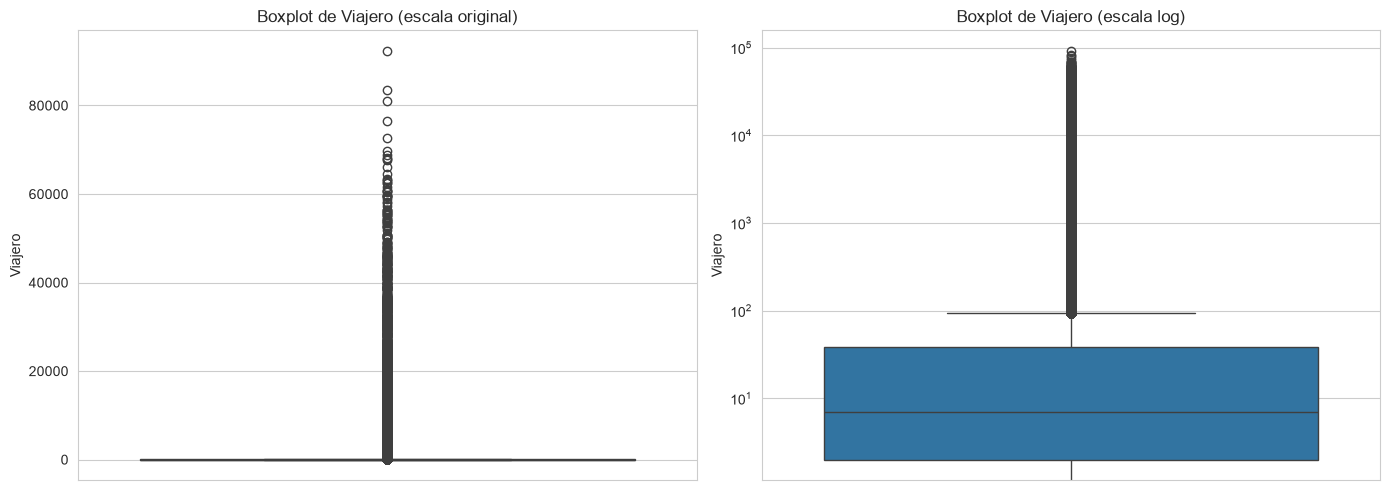

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(data=df, y='Viajero', ax=ax[0])
ax[0].set_title('Boxplot de Viajero (escala original)')
sns.boxplot(data=df, y='Viajero', ax=ax[1])
ax[1].set_yscale('log')
ax[1].set_title('Boxplot de Viajero (escala log)')
plt.tight_layout()
plt.show()

La distribucion de `Viajero` esta muy sesgada a la derecha: la mediana es 7 viajeros por registro
pero el maximo llega a mas de 92,000. Esto es esperable porque cada fila mezcla paises con muchisimo
turismo (Estados Unidos, El Salvador) con paises que casi no envian viajeros (Islas Cook, por ejemplo).
No son errores, son la naturaleza de los datos: hay que tenerlo en cuenta al momento de resumir por pais
o region, usando sumas totales en vez de promedios por fila.

In [10]:
outliers_por_tipo = df.groupby('Tipo de Viajero')['Viajero'].describe()
outliers_por_tipo

,count,mean,std,min,25%,50%,75%,max
Tipo de Viajero,,,,,,,,
Cruceristas,204.0,5413.735294,4225.763359,85.0,2094.0,4454.906604,7173.500000,21680.93357
Excursionista,19730.0,459.664690,1833.670984,0.0,2.0,10.000000,80.255455,38463.02606
Turista,117912.0,319.244255,2611.324160,0.0,2.0,6.000000,33.000000,83511.00000
Viajero,23190.0,192.825451,1281.234973,0.0,2.0,8.181818,44.000000,92336.03507


Separado por tipo de viajero se ve mejor: Turista tiene el rango mas amplio (hasta paises grandes
como EE.UU. en meses de alta afluencia), mientras Cruceristas tiene menos registros pero valores altos
concentrados (llegadas de cruceros completos). Ninguno de estos valores altos se ve como un error de
captura, son consistentes con paises/meses de alta afluencia conocida.

## 3. Nota sobre la categoria "Viajero"

Segun el enunciado del laboratorio, entre 2022 y 2023 la categoria de tipo de viajero "Viajero" cambio
de definicion (dejo de incluir comercio fronterizo y transito de alta frecuencia). Esto se confirma abajo:

In [11]:
tipo_anual = df.groupby(['Año','Tipo de Viajero'])['Viajero'].sum().unstack()
tipo_anual

Tipo de Viajero,Cruceristas,Excursionista,Turista,Viajero
Año,,,,
2009,81346.000000,2.640982e+05,1.616085e+06,6.724687e+04
2010,72488.000000,3.000031e+05,1.704781e+06,7.562685e+04
2011,72350.000000,3.241871e+05,1.755528e+06,7.939150e+04
2012,72846.000000,3.593042e+05,1.780237e+06,8.742810e+04
2013,71690.000000,3.791146e+05,1.910588e+06,7.077623e+04
2014,70601.000000,4.492579e+05,2.210919e+06,3.182365e+04
2015,77195.000000,5.051244e+05,2.412762e+06,4.656154e+04
2016,103712.000001,3.596031e+05,2.637424e+06,3.954781e+05
2017,129063.000004,5.828400e+05,2.724811e+06,4.847460e+05


Se ve claramente la caida de la categoria "Viajero" en 2023 (de ~1,060,806 en 2022 a ~330,882 en
2023) y que "Cruceristas" deja de reportarse como categoria separada a partir de 2023 (columna vacia).
Por eso, para todo el analisis de comportamiento temporal usamos **Turista + Excursionista**, que se
mantienen consistentes en toda la serie 2009-2026, tal como recomienda el enunciado.

In [12]:
df['metrica_principal'] = df['Tipo de Viajero'].isin(['Turista','Excursionista'])
print("Filas usadas en Turista+Excursionista:", df['metrica_principal'].sum(), "de", len(df))

Filas usadas en Turista+Excursionista: 137642 de 161036


## 4. Comportamiento temporal del numero de viajeros

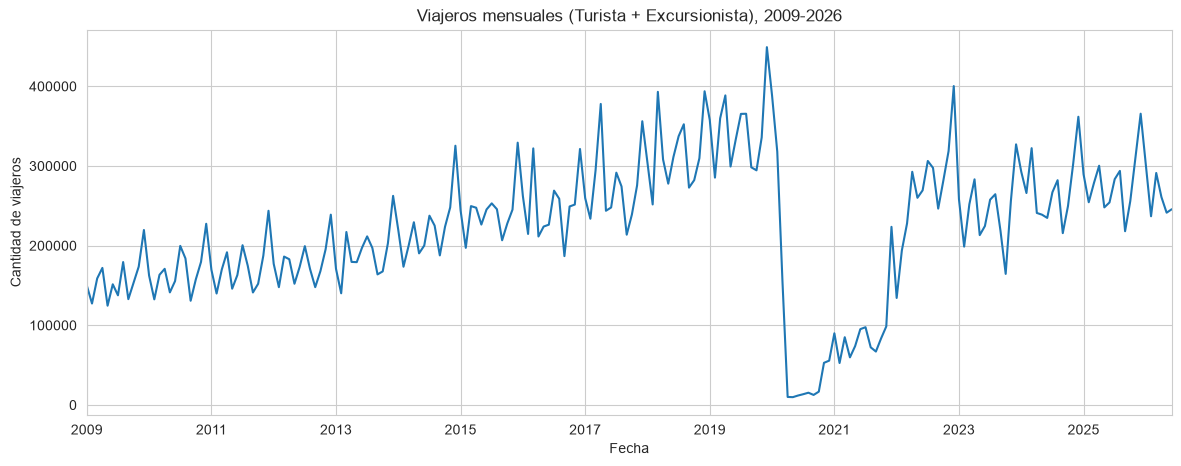

In [13]:
df['fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes cod'].astype(str) + '-01')

serie_total = (df[df['metrica_principal']]
               .groupby('fecha')['Viajero']
               .sum())

serie_total.plot(figsize=(14,5), title='Viajeros mensuales (Turista + Excursionista), 2009-2026')
plt.ylabel('Cantidad de viajeros')
plt.xlabel('Fecha')
plt.show()

Se observa una tendencia creciente desde 2009 hasta 2019, una caida abrupta en 2020 por la
pandemia de COVID-19, una recuperacion lenta en 2021-2022 y una vuelta a niveles cercanos a los de
antes de la pandemia entre 2023 y 2026. Tambien se nota un patron estacional dentro de cada año
(picos y valles que se repiten), que se vera con mas detalle al analizar la serie a fondo en la
siguiente entrega.

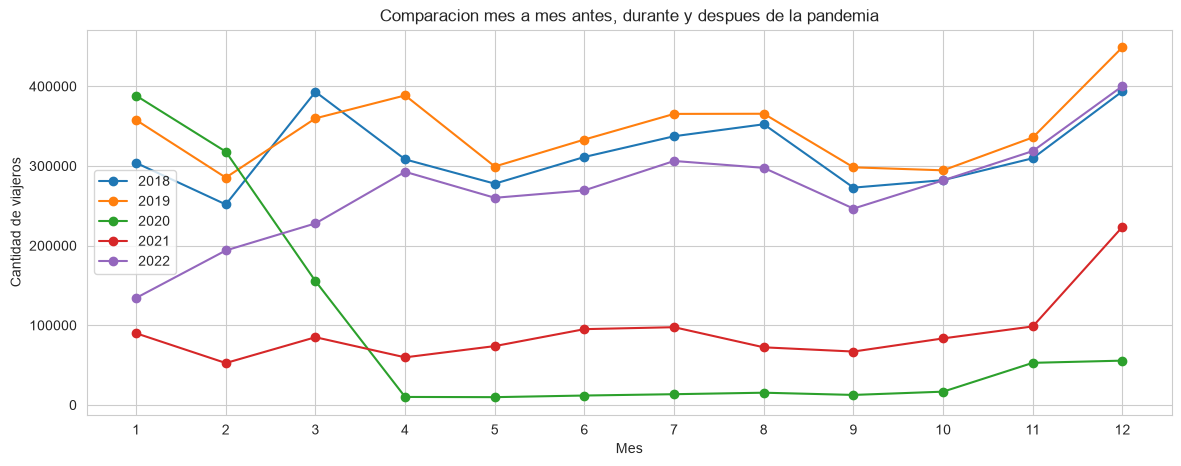

In [14]:
fig, ax = plt.subplots(figsize=(14,5))
for anio in [2018, 2019, 2020, 2021, 2022]:
    sub = serie_total[serie_total.index.year == anio]
    ax.plot(sub.index.month, sub.values, marker='o', label=str(anio))
ax.set_xticks(range(1,13))
ax.set_xlabel('Mes')
ax.set_ylabel('Cantidad de viajeros')
ax.set_title('Comparacion mes a mes antes, durante y despues de la pandemia')
ax.legend()
plt.show()

Este grafico muestra bien el efecto de la pandemia: 2018 y 2019 tienen un comportamiento
similar y estable, 2020 se desploma a partir de marzo (cuando cerraron fronteras), 2021 se mantiene
muy bajo casi todo el año, y 2022 empieza a recuperarse aunque sin llegar todavia a niveles de 2019.

## 5. Paises con mayor cantidad de viajeros

In [15]:
top_paises = (df[df['metrica_principal']]
              .groupby('País')['Viajero']
              .sum()
              .sort_values(ascending=False)
              .head(10))

top_paises

País
El Salvador                  1.407914e+07
Guatemala                    1.387039e+07
Estados Unidos de América    6.965680e+06
Honduras                     2.520974e+06
México                       1.678423e+06
Belice                       9.161011e+05
Costa Rica                   8.602407e+05
Nicaragua                    8.111454e+05
Colombia                     5.494947e+05
Canadá                       5.167079e+05
Name: Viajero, dtype: float64

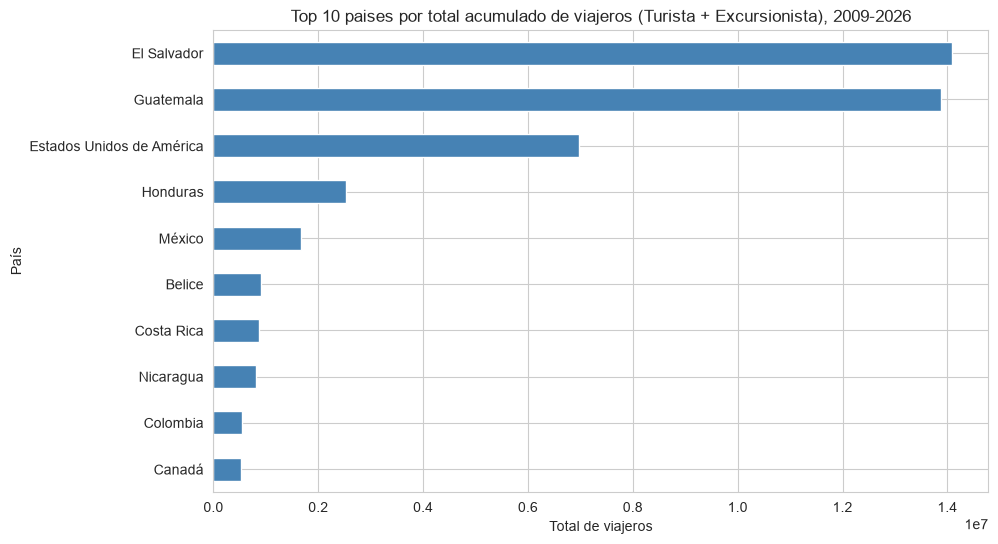

In [16]:
top_paises.sort_values().plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 10 paises por total acumulado de viajeros (Turista + Excursionista), 2009-2026')
plt.xlabel('Total de viajeros')
plt.show()

El Salvador, Guatemala y Estados Unidos concentran la mayor parte del turismo acumulado. El
Salvador y Guatemala se explican por movilidad terrestre fronteriza cotidiana; que Guatemala
aparezca como "pais de residencia" es coherente con que estos registros migratorios tambien
cuentan a residentes guatemaltecos que regresan de un viaje al extranjero, no solo a extranjeros
que ingresan. Estados Unidos es el mercado de largo alcance mas grande, y Honduras (4to lugar)
es el otro vecino con movilidad terrestre relevante. Esto sugiere que buena parte del "turismo"
en estos datos en realidad corresponde a movimiento fronterizo regional y a retorno de residentes.

## 6. Regiones con mayor cantidad de viajeros

In [17]:
top_regiones = (df[df['metrica_principal']]
                .groupby('Región dos')['Viajero']
                .sum()
                .sort_values(ascending=False))

top_regiones

Región dos
América Del Centro             3.328393e+07
América Del Norte              9.160810e+06
Europa                         2.149271e+06
América Del Sur y el Caribe    1.413590e+06
Asia                           4.103335e+05
Oceanía                        1.355054e+05
Oriente Medio                  1.337352e+05
Otros Paises Del Mundo         2.391430e+04
0                              8.210000e+02
Name: Viajero, dtype: float64

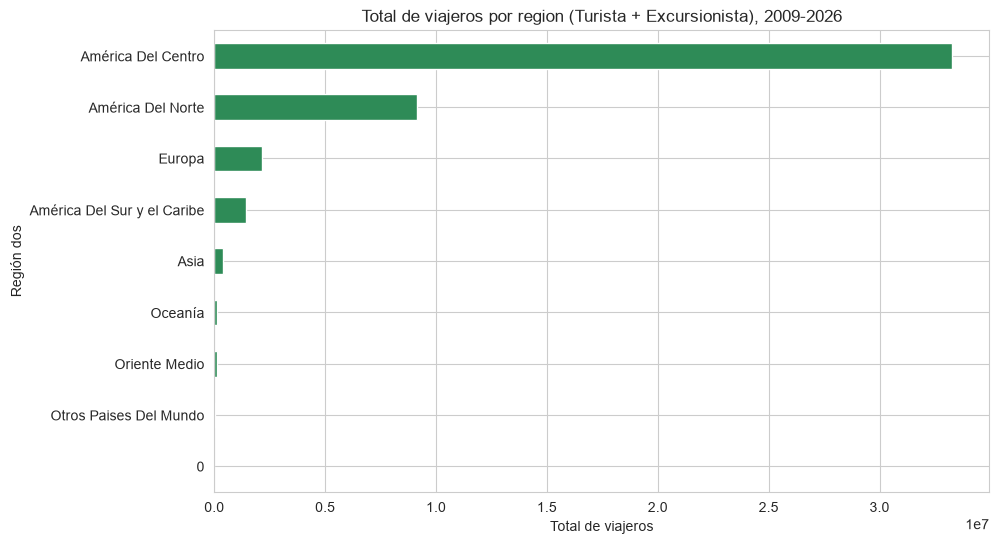

In [18]:
top_regiones.sort_values().plot(kind='barh', figsize=(10,6), color='seagreen')
plt.title('Total de viajeros por region (Turista + Excursionista), 2009-2026')
plt.xlabel('Total de viajeros')
plt.show()

America del Centro domina por mucho el total, seguida de America del Norte. Esto confirma lo
visto con los paises: el turismo de Guatemala es mayormente regional (Centroamerica), con Estados
Unidos y Canada como el principal mercado de fuera de la region.

## 7. Vias de ingreso y fronteras mas utilizadas

In [19]:
top_vias = (df[df['metrica_principal']]
            .groupby('Vía')['Viajero']
            .sum()
            .sort_values(ascending=False))

top_vias

Vía
Terrestre    2.759225e+07
Aérea        1.901942e+07
Marítima     1.002410e+05
Name: Viajero, dtype: float64

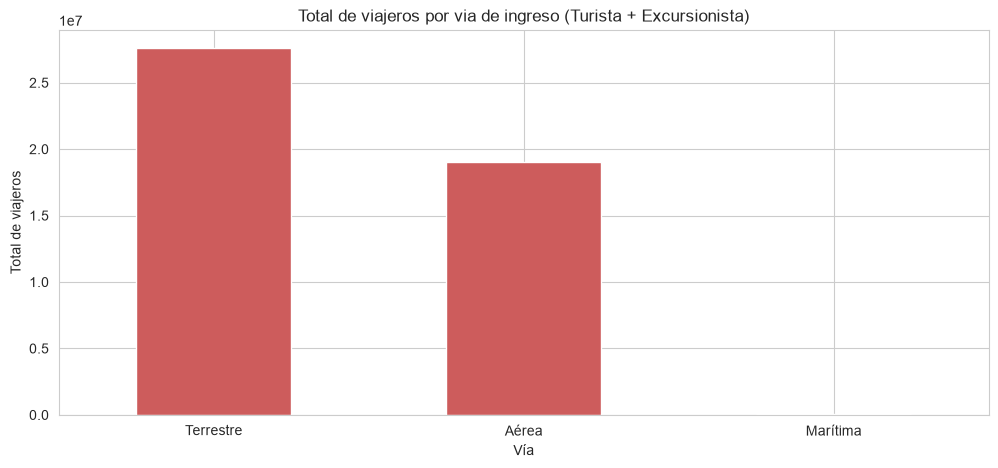

In [20]:
top_vias.plot(kind='bar', color='indianred')
plt.title('Total de viajeros por via de ingreso (Turista + Excursionista)')
plt.ylabel('Total de viajeros')
plt.xticks(rotation=0)
plt.show()

La via Terrestre es la mas utilizada, seguida por la Aerea aunque con una brecha considerable
(Terrestre ~27.6M vs Aerea ~19.0M viajeros acumulados). La via Maritima practicamente
no aparece en Turista+Excursionista porque los cruceros se registran bajo el tipo de viajero
"Cruceristas", que es una categoria distinta. Esto es importante: si se construye la serie de la via
Maritima con esta metrica, va a salir casi en cero, y hay que aclararlo en el analisis.

In [21]:
top_fronteras = (df[df['metrica_principal']]
                 .groupby('Frontera')['Viajero']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

top_fronteras

Frontera
01 La Aurora                     1.898998e+07
07 Valle Nuevo                   1.014305e+07
09 San Cristóbal                 4.183632e+06
08 Pedro de Alvarado             3.764229e+06
10 La Ermita (Nueva Anguiatú)    2.587072e+06
20 Melchor de Mencos             1.782864e+06
13 El Cinchado / El Corinto      1.213485e+06
11 Agua Caliente                 9.224195e+05
12 El Florido                    9.103735e+05
15 El Carmen                     8.526631e+05
Name: Viajero, dtype: float64

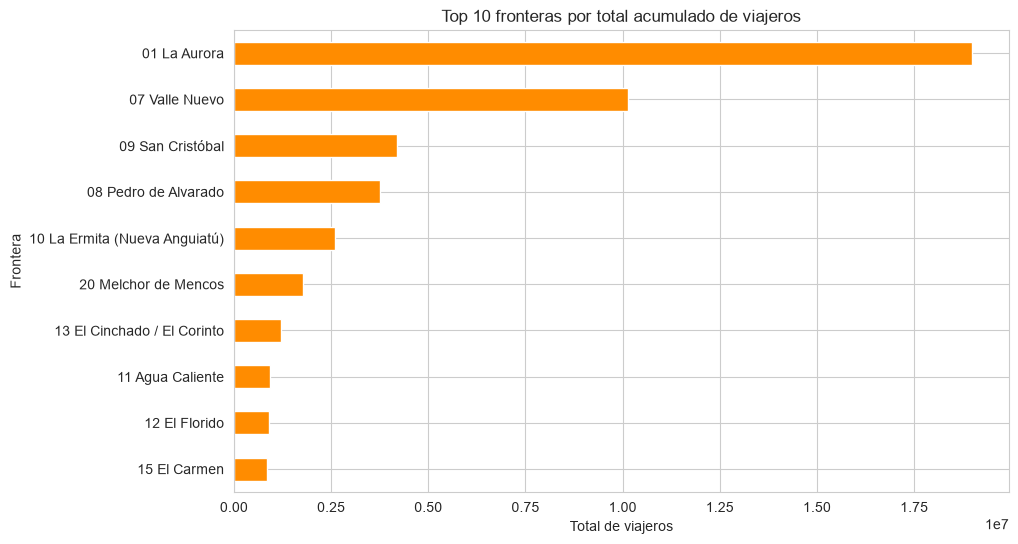

In [22]:
top_fronteras.sort_values().plot(kind='barh', figsize=(10,6), color='darkorange')
plt.title('Top 10 fronteras por total acumulado de viajeros')
plt.xlabel('Total de viajeros')
plt.show()

La Aurora (aeropuerto principal) y los pasos fronterizos terrestres con El Salvador y Honduras
concentran la mayoria del ingreso de viajeros, consistente con lo que ya se vio por pais y por via.

## 8. Estadisticas descriptivas adicionales

In [23]:
resumen_anual = (df[df['metrica_principal']]
                 .groupby('Año')['Viajero']
                 .sum())

resumen_anual

Año
2009    1.880183e+06
2010    2.004784e+06
2011    2.079715e+06
2012    2.139541e+06
2013    2.289703e+06
2014    2.660177e+06
2015    2.917886e+06
2016    2.997027e+06
2017    3.307651e+06
2018    3.793761e+06
2019    4.132251e+06
2020    1.059770e+06
2021    1.098964e+06
2022    3.229329e+06
2023    2.917827e+06
2024    3.274436e+06
2025    3.352289e+06
2026    1.576619e+06
Name: Viajero, dtype: float64

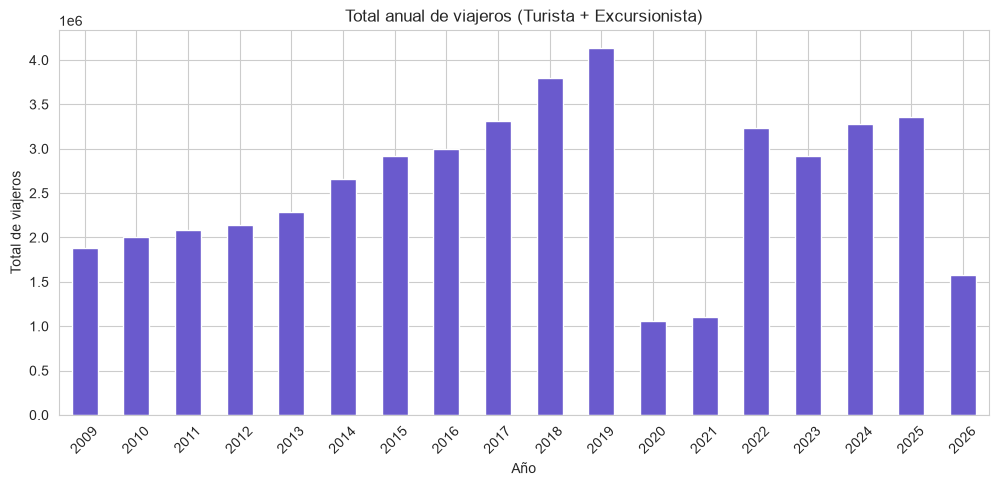

In [24]:
resumen_anual.plot(kind='bar', figsize=(12,5), color='slateblue')
plt.title('Total anual de viajeros (Turista + Excursionista)')
plt.ylabel('Total de viajeros')
plt.xticks(rotation=45)
plt.show()

Nota: 2009 y 2026 son años parciales en cuanto a lo que se ve en el grafico de barras (2026 solo
llega hasta junio), asi que no son comparables directamente contra un año completo como 2019.

In [25]:
crecimiento = resumen_anual.pct_change() * 100
crecimiento.round(1)

Año
2009      NaN
2010      6.6
2011      3.7
2012      2.9
2013      7.0
2014     16.2
2015      9.7
2016      2.7
2017     10.4
2018     14.7
2019      8.9
2020    -74.4
2021      3.7
2022    193.9
2023     -9.6
2024     12.2
2025      2.4
2026    -53.0
Name: Viajero, dtype: float64

La caida mas fuerte es 2020 (-73% aprox. vs 2019), y la recuperacion mas fuerte es 2021 a 2022
cuando se reabren fronteras casi por completo. De 2023 en adelante el crecimiento se estabiliza en
tasas mas moderadas, cercanas a las de antes de la pandemia.

In [26]:
df[df['metrica_principal']]['Viajero'].describe()

count    137642.000000
mean        339.372524
std        2515.137946
min           0.000000
25%           2.000000
50%           7.000000
75%          37.000000
max       83511.000000
Name: Viajero, dtype: float64

Podemos concluir para el EDA que el dataset esta limpio (sin nulos, sin duplicados reales), tiene algunos valores
decimales que son validos y no errores, y muestra con claridad tres cosas: una tendencia de crecimiento
de largo plazo, un quiebre fuerte por la pandemia en 2020-2021, y una concentracion del turismo en
paises y fronteras centroamericanas. Estos hallazgos ya dan una buena base para construir y modelar
las series de tiempo en la siguiente parte del laboratorio.

## 9. Division en entrenamiento y prueba (70/30)

El corte se hace por tiempo, no al azar, porque en series de tiempo el orden importa: no tiene
sentido "prueba" un modelo con meses que quedaron antes que los de entrenamiento.

Tomamos el 70% inicial de los meses (2009-01 a 2021-03, 147 meses) como entrenamiento, y el 30%
restante (2021-04 a 2026-06, 63 meses) como prueba.

In [27]:
fecha_corte = '2021-04-01'

df_train = df[df['fecha'] < fecha_corte].copy()
df_test = df[df['fecha'] >= fecha_corte].copy()

print("Entrenamiento:", df_train['fecha'].min(), "a", df_train['fecha'].max(), "-", df_train['fecha'].nunique(), "meses")
print("Prueba:       ", df_test['fecha'].min(), "a", df_test['fecha'].max(), "-", df_test['fecha'].nunique(), "meses")
print(f"Proporcion train: {df_train['fecha'].nunique()/df['fecha'].nunique():.1%}")

Entrenamiento: 2009-01-01 00:00:00 a 2021-03-01 00:00:00 - 147 meses
Prueba:        2021-04-01 00:00:00 a 2026-06-01 00:00:00 - 63 meses
Proporcion train: 70.0%


In [28]:
df_train.to_csv('train_raw.csv', index=False)
df_test.to_csv('test_raw.csv', index=False)
print("Archivos guardados: train_raw.csv, test_raw.csv")

Archivos guardados: train_raw.csv, test_raw.csv


## 10. Construccion de series de tiempo mensuales

Vamos a construir 8 series en total, todas con frecuencia mensual (`MS`) y sin huecos (los meses sin
registros para una categoria se rellenan con 0):

1. **Serie obligatoria**: total mensual, usando Turista + Excursionista
2. **Vias de ingreso** (Aerea, Terrestre, Maritima): usando el total de viajeros (todos los tipos).
   Se decidio asi porque filtrar solo Turista+Excursionista deja la via Maritima casi en cero, ya que
   los cruceros se registran como tipo "Cruceristas" y no como Turista. Usando el total, la serie
   Maritima si refleja el trafico real por esa via.
3. **Tipo de viajero** (Turista, Excursionista, Cruceristas, Viajero): una serie por cada tipo, sin
   filtrar, para poder comparar los tipos entre si.

Cada serie se construye a partir del conjunto de **entrenamiento**.

In [29]:
def construir_serie(data, filtro=None, rango_completo=None):
    '''Agrega Viajero por mes y devuelve una serie con frecuencia mensual completa (sin huecos).'''
    d = data if filtro is None else data[filtro]
    serie = d.groupby('fecha')['Viajero'].sum()
    if rango_completo is not None:
        serie = serie.reindex(rango_completo, fill_value=0)
    serie.index.freq = 'MS'
    return serie

rango_train = pd.date_range(df_train['fecha'].min(), df_train['fecha'].max(), freq='MS')
print(f"Rango de entrenamiento: {rango_train.min()} a {rango_train.max()}, {len(rango_train)} meses")

Rango de entrenamiento: 2009-01-01 00:00:00 a 2021-03-01 00:00:00, 147 meses


### 10.1 Serie obligatoria: Total mensual (Turista + Excursionista)

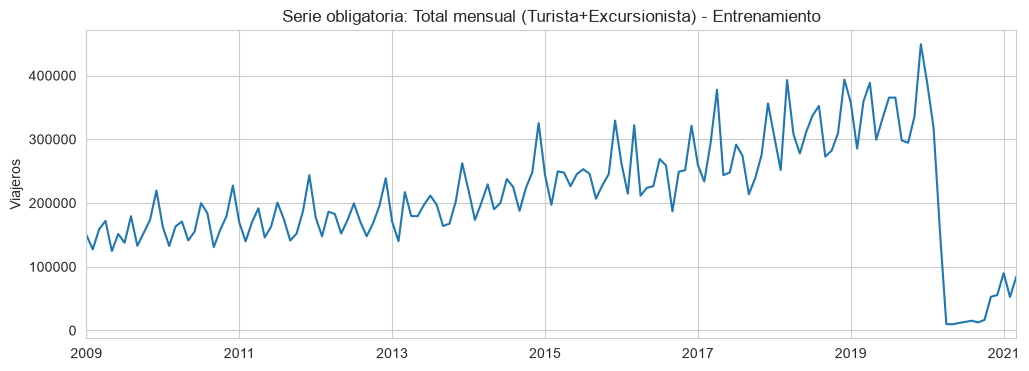

2009-01-01    149944.029346
2009-02-01    127303.692202
2009-03-01    158795.673821
2009-04-01    172013.467694
2009-05-01    124559.524354
Freq: MS, Name: Viajero, dtype: float64

In [30]:
filtro_te = df_train['Tipo de Viajero'].isin(['Turista','Excursionista'])
serie_total_train = construir_serie(df_train, filtro_te, rango_train)

serie_total_train.plot(figsize=(12,4), title='Serie obligatoria: Total mensual (Turista+Excursionista) - Entrenamiento')
plt.ylabel('Viajeros')
plt.show()
serie_total_train.head()

### 10.2 Series por Via de ingreso (total de viajeros, todos los tipos)

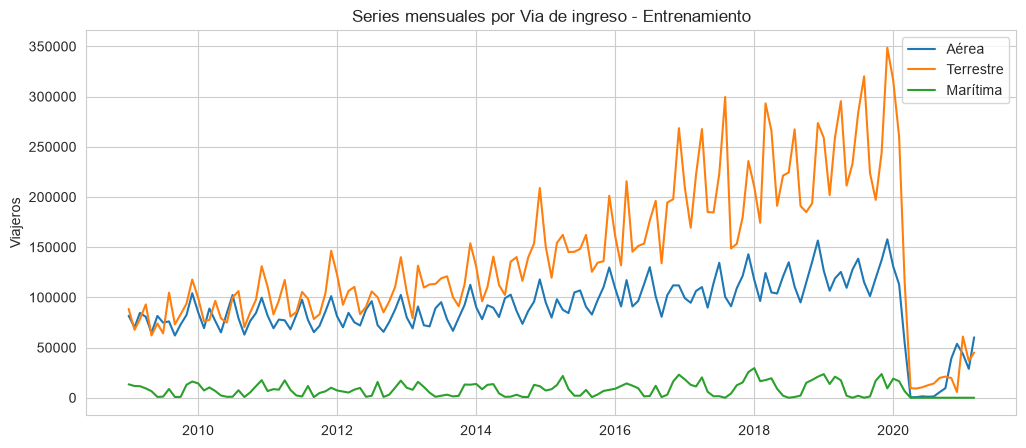

Aérea - inicio: 2009-01-01 00:00:00 fin: 2021-03-01 00:00:00 frecuencia: MS meses en cero: 0
Terrestre - inicio: 2009-01-01 00:00:00 fin: 2021-03-01 00:00:00 frecuencia: MS meses en cero: 0
Marítima - inicio: 2009-01-01 00:00:00 fin: 2021-03-01 00:00:00 frecuencia: MS meses en cero: 16


In [31]:
vias = ['Aérea', 'Terrestre', 'Marítima']
series_via = {}

for via in vias:
    filtro = df_train['Vía'] == via
    series_via[via] = construir_serie(df_train, filtro, rango_train)

fig, ax = plt.subplots(figsize=(12,5))
for via, s in series_via.items():
    ax.plot(s.index, s.values, label=via)
ax.set_title('Series mensuales por Via de ingreso - Entrenamiento')
ax.set_ylabel('Viajeros')
ax.legend()
plt.show()

for via, s in series_via.items():
    print(via, "- inicio:", s.index.min(), "fin:", s.index.max(), "frecuencia:", s.index.freqstr, "meses en cero:", (s==0).sum())

Terrestre y Aerea tienen datos consistentes en todo el periodo. Maritima tiene bastantes meses
en cero al inicio y muestra un comportamiento mas irregular, esperable porque depende de temporadas
de cruceros y de menos operaciones que las otras dos vias.

### 10.3 Series por Tipo de viajero (sin filtrar)

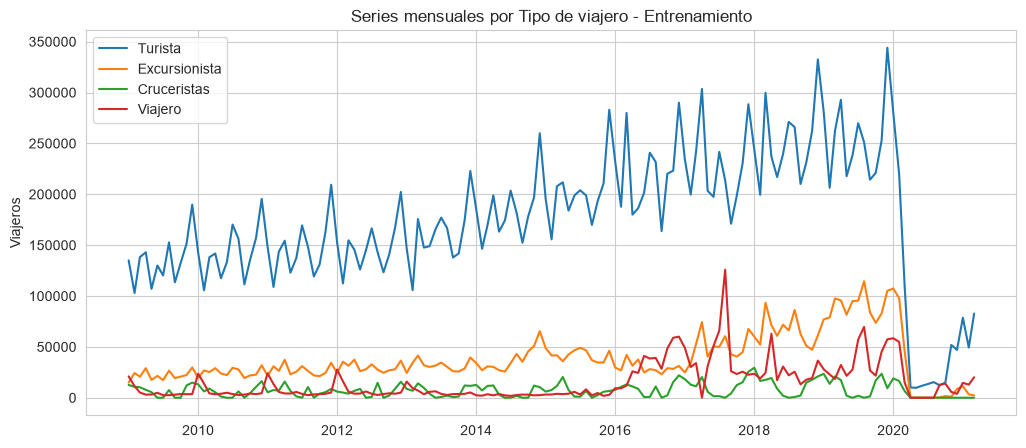

Turista - inicio: 2009-01-01 00:00:00 fin: 2021-03-01 00:00:00 frecuencia: MS meses en cero: 0
Excursionista - inicio: 2009-01-01 00:00:00 fin: 2021-03-01 00:00:00 frecuencia: MS meses en cero: 5
Cruceristas - inicio: 2009-01-01 00:00:00 fin: 2021-03-01 00:00:00 frecuencia: MS meses en cero: 34
Viajero - inicio: 2009-01-01 00:00:00 fin: 2021-03-01 00:00:00 frecuencia: MS meses en cero: 5


In [32]:
tipos = ['Turista', 'Excursionista', 'Cruceristas', 'Viajero']
series_tipo = {}

for tipo in tipos:
    filtro = df_train['Tipo de Viajero'] == tipo
    series_tipo[tipo] = construir_serie(df_train, filtro, rango_train)

fig, ax = plt.subplots(figsize=(12,5))
for tipo, s in series_tipo.items():
    ax.plot(s.index, s.values, label=tipo)
ax.set_title('Series mensuales por Tipo de viajero - Entrenamiento')
ax.set_ylabel('Viajeros')
ax.legend()
plt.show()

for tipo, s in series_tipo.items():
    print(tipo, "- inicio:", s.index.min(), "fin:", s.index.max(), "frecuencia:", s.index.freqstr, "meses en cero:", (s==0).sum())

Turista domina en volumen sobre los demas tipos, como ya se habia visto en el EDA. Cruceristas
se mantiene bajo y con menos variacion, y Viajero muestra la caida hacia el final del entrenamiento
que ya identificamos (cambio de definicion en 2022-2023). Esto no se corrige: se deja tal cual porque
refleja un cambio real en como se reporta esa categoria, y se analizara como tal en la siguiente parte.

## 11. Resumen de series

| # | Serie | Filtro usado | Meses (train) |
|---|-------|-------------|----------------|
| 1 | Total mensual (obligatoria) | Turista + Excursionista | 147 |
| 2 | Via Aerea | Total de viajeros | 147 |
| 3 | Via Terrestre | Total de viajeros | 147 |
| 4 | Via Maritima | Total de viajeros | 147 |
| 5 | Tipo Turista | Sin filtrar | 147 |
| 6 | Tipo Excursionista | Sin filtrar | 147 |
| 7 | Tipo Cruceristas | Sin filtrar | 147 |
| 8 | Tipo Viajero | Sin filtrar | 147 |

Con esto tenemos 8 series (obligatoria + 3 de via + 4 de tipo), todas con frecuencia mensual completa
y sin huecos, listas para el analisis individual (grafico, descomposicion, estacionariedad y modelado)
que corresponde a la siguiente parte del laboratorio.

## 12. Analisis de la serie obligatoria: Total mensual (Turista + Excursionista)

A partir de aqui se desarrolla el punto 4 del laboratorio: el analisis completo de una serie de tiempo (grafico, descomposicion, estacionariedad, seleccion de modelo ARIMA, comparacion con Prophet/Holt-Winters/suavizamiento exponencial/seasonal naive, prediccion y comparacion de metricas). Se hace primero completo para la **serie obligatoria** (total mensual) y despues, en la seccion 13, se empaqueta como funcion para replicarlo sobre las otras 7 series (vias de ingreso y tipos de viajero).

In [33]:
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm
from prophet import Prophet

print("ok")

Importing plotly failed. Interactive plots will not work.


ok


### 12.0 Serie de prueba correspondiente

Para poder evaluar predicciones (punto i) necesitamos tambien la serie del periodo de prueba, construida igual que la de entrenamiento pero a partir de `df_test`.

In [34]:
rango_test = pd.date_range(df_test['fecha'].min(), df_test['fecha'].max(), freq='MS')
filtro_te_test = df_test['Tipo de Viajero'].isin(['Turista','Excursionista'])
serie_total_test = construir_serie(df_test, filtro_te_test, rango_test)

print("Prueba - inicio:", serie_total_test.index.min(), "fin:", serie_total_test.index.max(),
      "meses:", len(serie_total_test))

Prueba - inicio: 2021-04-01 00:00:00 fin: 2026-06-01 00:00:00 meses: 63


### 12.a Inicio, fin y frecuencia

In [35]:
print("Serie obligatoria - Total mensual (Turista+Excursionista)")
print("Entrenamiento: inicio =", serie_total_train.index.min().date(),
      "| fin =", serie_total_train.index.max().date(),
      "| frecuencia =", serie_total_train.index.freqstr,
      "| n =", len(serie_total_train))
print("Prueba:        inicio =", serie_total_test.index.min().date(),
      "| fin =", serie_total_test.index.max().date(),
      "| frecuencia =", serie_total_test.index.freqstr,
      "| n =", len(serie_total_test))

Serie obligatoria - Total mensual (Turista+Excursionista)
Entrenamiento: inicio = 2009-01-01 | fin = 2021-03-01 | frecuencia = MS | n = 147
Prueba:        inicio = 2021-04-01 | fin = 2026-06-01 | frecuencia = MS | n = 63


La serie tiene frecuencia mensual (`MS`, inicio de cada mes) y no tiene huecos. El entrenamiento cubre 147 meses (enero 2009 a marzo 2021) y la prueba 63 meses (abril 2021 a junio 2026).

### 12.b Grafico completo (entrenamiento + prueba) e interpretacion

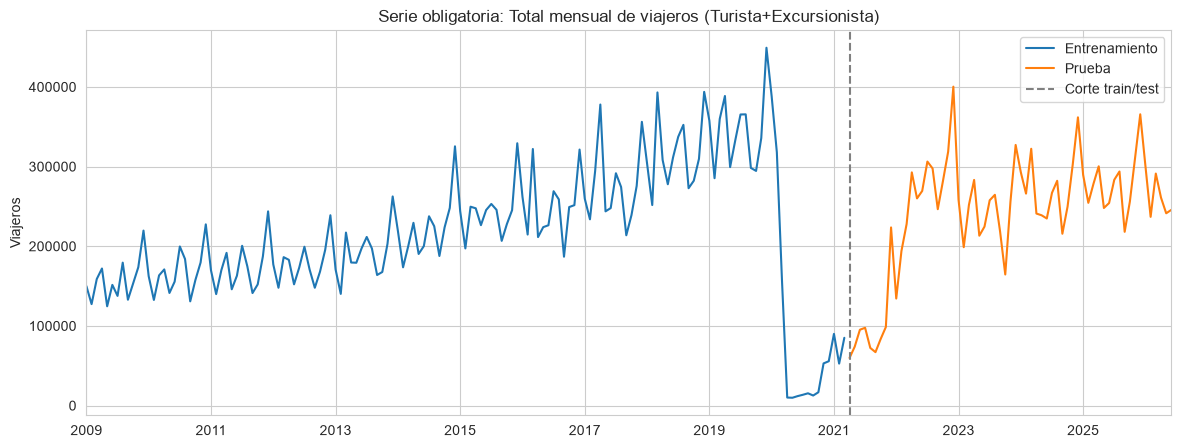

In [36]:
fig, ax = plt.subplots(figsize=(14,5))
serie_total_train.plot(ax=ax, label='Entrenamiento')
serie_total_test.plot(ax=ax, label='Prueba')
ax.axvline(serie_total_test.index.min(), color='gray', linestyle='--', label='Corte train/test')
ax.set_title('Serie obligatoria: Total mensual de viajeros (Turista+Excursionista)')
ax.set_ylabel('Viajeros')
ax.legend()
plt.show()

A primera vista se distinguen: (1) una tendencia creciente clara entre 2009 y 2019; (2) un quiebre abrupto por la pandemia justo antes del corte train/test (2020-2021); (3) un patron estacional que se repite cada 12 meses (picos y valles dentro de cada año); y (4) en el conjunto de prueba, una recuperacion pronunciada seguida de una nueva estabilizacion. Esta ultima parte es la mas dificil de predecir, porque el modelo se entrena solo con datos hasta marzo 2021, es decir, sin haber visto todavia la recuperacion pos-pandemia.

### 12.c Descomposicion de la serie y estacionariedad en media y varianza

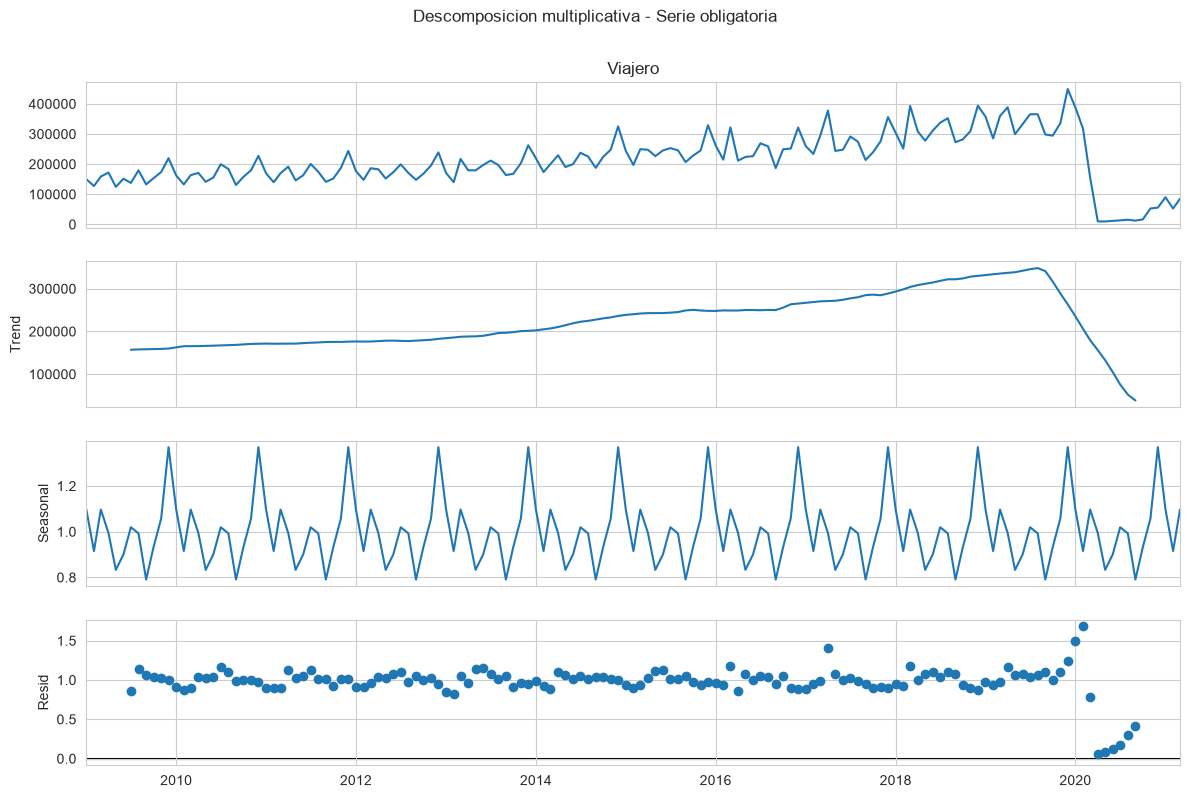

Desviacion estandar del residuo (aditivo): 32216.1
Desviacion estandar del residuo (multiplicativo, relativo): 0.205
1ra mitad (2009-2015): std=36649, media=182167
2da mitad (2015-2021): std=108883, media=245835


In [37]:
decomp_add = seasonal_decompose(serie_total_train, model='additive', period=12)
decomp_mul = seasonal_decompose(serie_total_train, model='multiplicative', period=12)

fig = decomp_mul.plot()
fig.set_size_inches(12,8)
fig.suptitle('Descomposicion multiplicativa - Serie obligatoria', y=1.02)
plt.show()

print("Desviacion estandar del residuo (aditivo):", round(np.nanstd(decomp_add.resid),1))
print("Desviacion estandar del residuo (multiplicativo, relativo):", round(np.nanstd(decomp_mul.resid),3))

primera_mitad = serie_total_train.iloc[:73]
segunda_mitad = serie_total_train.iloc[73:]
print(f"1ra mitad (2009-2015): std={primera_mitad.std():.0f}, media={primera_mitad.mean():.0f}")
print(f"2da mitad (2015-2021): std={segunda_mitad.std():.0f}, media={segunda_mitad.mean():.0f}")

La descomposicion muestra una tendencia con crecimiento sostenido hasta 2019 y una caida marcada en 2020, y una componente estacional con picos recurrentes cada 12 meses (temporadas altas de turismo).

**Estacionariedad en media:** no hay estacionariedad en media — la tendencia no es constante (crece, cae, se recupera), por lo que la media de la serie cambia con el tiempo.

**Estacionariedad en varianza:** al comparar la primera mitad del entrenamiento (2009-2015: std ≈ 36,649, media ≈ 182,167) contra la segunda mitad (2015-2021: std ≈ 108,883, media ≈ 245,835), la variabilidad crece junto con el nivel de la serie. El modelo multiplicativo describe esto mejor que el aditivo (la amplitud estacional es proporcional al nivel), lo que confirma que tampoco hay estacionariedad en varianza.

### 12.d ¿Es necesaria una transformacion?

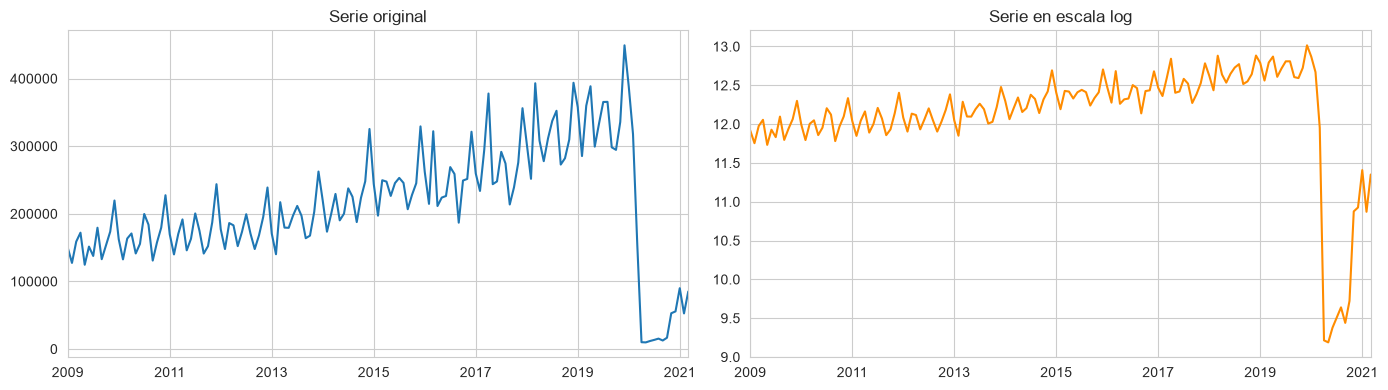

Desviacion estandar del residuo (log, aditivo): 0.298


In [38]:
serie_log = np.log1p(serie_total_train)

fig, axes = plt.subplots(1,2, figsize=(14,4))
serie_total_train.plot(ax=axes[0], title='Serie original')
serie_log.plot(ax=axes[1], title='Serie en escala log', color='darkorange')
plt.tight_layout()
plt.show()

decomp_log = seasonal_decompose(serie_log, model='additive', period=12)
print("Desviacion estandar del residuo (log, aditivo):", round(np.nanstd(decomp_log.resid),3))

Si, es necesaria una transformacion. Como la varianza crece con el nivel de la serie (heterocedasticidad, confirmado en el punto anterior), aplicamos **logaritmo natural** (`log1p`, que ademas admite series con ceros, util mas adelante para las series de via Maritima y Cruceristas). Con el log, un modelo aditivo sobre la serie transformada equivale a un modelo multiplicativo sobre la escala original, y la amplitud estacional se vuelve mas estable en el tiempo. De aqui en adelante trabajamos sobre `serie_log` para el modelado ARIMA.

### 12.e ¿Es estacionaria en media? ACF y prueba de Dickey-Fuller Aumentada

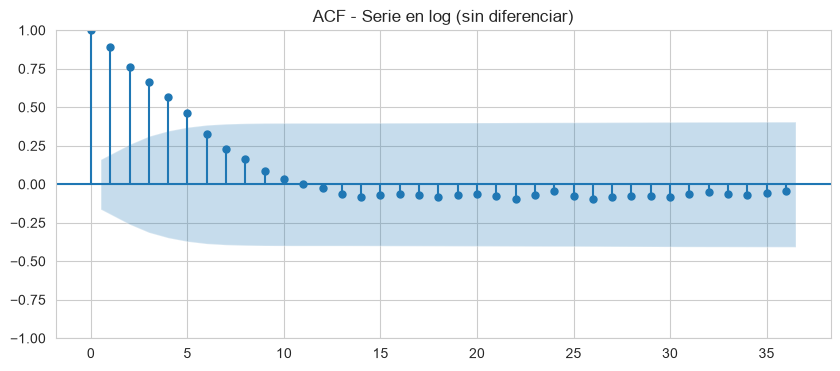

ADF (log, sin diferenciar): estadistico=-2.499, p-valor=0.1157
Valores criticos: {'1%': np.float64(-3.480118600110386), '5%': np.float64(-2.8833618426136196), '10%': np.float64(-2.578407034974382)}


In [39]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(serie_log, lags=36, ax=ax)
ax.set_title('ACF - Serie en log (sin diferenciar)')
plt.show()

adf_log = adfuller(serie_log, autolag='AIC')
print(f"ADF (log, sin diferenciar): estadistico={adf_log[0]:.3f}, p-valor={adf_log[1]:.4f}")
print("Valores criticos:", adf_log[4])

El ACF decae muy lentamente (no baja a valores cercanos a 0 sino hasta despues de muchos rezagos, con un patron ondulado por la estacionalidad) — ese decaimiento lento es la firma clasica de una serie no estacionaria en media.

La prueba ADF lo confirma: p-valor = 0.1157 (> 0.05), por lo que **no se rechaza la hipotesis nula de raiz unitaria** — la serie en log no es estacionaria en media. Es necesario diferenciar.

In [40]:
serie_log_diff1 = serie_log.diff().dropna()
serie_log_diff12 = serie_log.diff(12).dropna()
serie_log_diff_both = serie_log.diff().diff(12).dropna()

for nombre, s in [('diferencia regular (d=1)', serie_log_diff1),
                   ('diferencia estacional (D=1, s=12)', serie_log_diff12),
                   ('diferencia regular + estacional (d=1, D=1)', serie_log_diff_both)]:
    adf = adfuller(s, autolag='AIC')
    print(f"{nombre}: ADF stat={adf[0]:.3f}, p-valor={adf[1]:.4f}")

diferencia regular (d=1): ADF stat=-3.085, p-valor=0.0277
diferencia estacional (D=1, s=12): ADF stat=0.066, p-valor=0.9636
diferencia regular + estacional (d=1, D=1): ADF stat=-6.539, p-valor=0.0000


Con una sola diferencia regular (d=1) el p-valor ya baja de 0.05 (0.0277), pero la serie diferenciada una vez todavia conserva estructura estacional visible. Diferenciar solo en la parte estacional (D=1) no alcanza (p=0.9636, sigue sin ser estacionaria). La combinacion **d=1 y D=1** (diferencia regular + diferencia estacional de 12 meses) da el resultado ADF mas contundente (p-valor ≈ 0.0000), y es la que usamos como punto de partida para el modelo ARIMA/SARIMA.

### 12.f Seleccion de p, d, q (y P, D, Q estacionales) con ACF/PACF, y comparacion con auto_arima

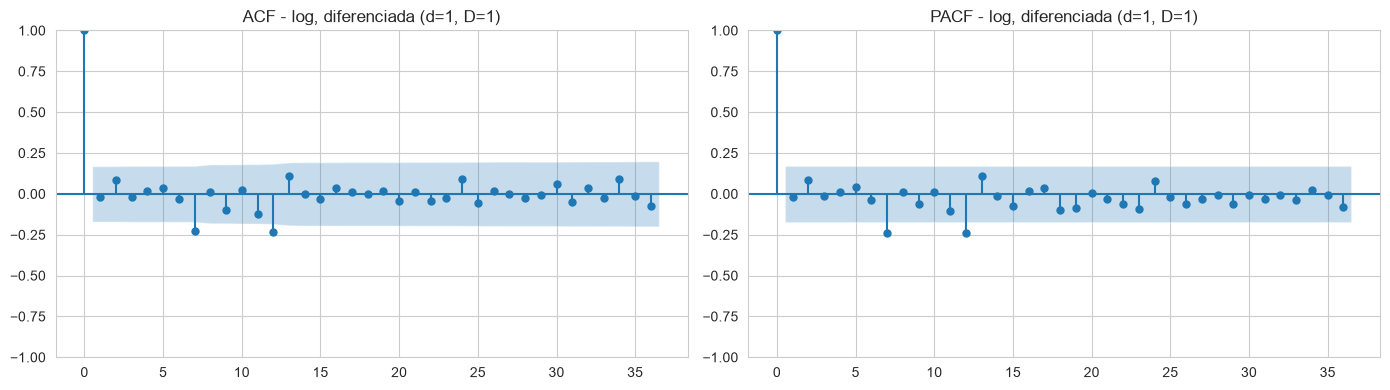

In [41]:
fig, axes = plt.subplots(1,2, figsize=(14,4))
plot_acf(serie_log_diff_both, lags=36, ax=axes[0])
axes[0].set_title('ACF - log, diferenciada (d=1, D=1)')
plot_pacf(serie_log_diff_both, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF - log, diferenciada (d=1, D=1)')
plt.tight_layout()
plt.show()

Con la serie ya diferenciada (d=1, D=1): tanto el ACF como el PACF muestran un pico claro en el rezago 1 (componente no estacional) y otro en el rezago 12 (componente estacional), consistente con un proceso ARMA(1,1) en la parte regular y un termino estacional (1,1) en el rezago 12. De ahi proponemos como punto de partida manual **SARIMA(1,1,1)(1,1,1)[12]**.

In [42]:
auto_model = pm.auto_arima(serie_log, seasonal=True, m=12, trace=True, stepwise=True,
                            suppress_warnings=True, error_action='ignore',
                            max_p=3, max_q=3, max_P=2, max_Q=2)
print(auto_model.summary())
print("\nOrden propuesto por auto_arima:", auto_model.order, "x", auto_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=70.781, Time=0.80 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=317.591, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=76.934, Time=0.51 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=193.910, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1153.227, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=86.990, Time=0.36 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=82.858, Time=0.62 sec
 ARIMA(2,0,2)(2,0,1)[12] intercept   : AIC=72.832, Time=1.51 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=68.494, Time=1.56 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=76.712, Time=1.10 sec
 ARIMA(2,0,2)(2,0,2)[12] intercept   : AIC=70.851, Time=1.74 sec
 ARIMA(1,0,2)(1,0,2)[12] intercept   : AIC=67.998, Time=1.28 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=74.713, Time=0.70 sec
 ARIMA(1,0,2)(1,0,1)[12] intercept   : AIC=68.504, Time=0.67 sec
 ARIMA(1,0,2)(2,0,2)[12] intercept   : AIC=

`auto_arima` propone SARIMA(1,0,1)(1,0,2)[12], es decir, **sin diferenciar** (d=0, D=0). Esto contrasta con nuestra eleccion manual (d=1, D=1) basada en el ADF. ¿Tiene sentido? Parcialmente: `auto_arima` usa por defecto pruebas de estacionariedad distintas (KPSS para la parte regular, OCSB para la estacional), mas permisivas que el ADF, y compensa la falta de diferenciacion con coeficientes AR muy cercanos a 1 (ar.L1=0.90, ar.S.L12=0.94), casi una raiz unitaria disfrazada de proceso estacionario. Un modelo con AR tan cerca de la frontera de no-invertibilidad suele ser menos estable para pronosticar a 63 meses (todo el conjunto de prueba) que una diferenciacion explicita. Por eso en el siguiente punto comparamos esta propuesta contra los modelos diferenciados usando AIC/BIC y residuos, en vez de quedarnos solo con la propuesta automatica.

### 12.g Varios modelos ARIMA/SARIMA: seleccion por residuos, AIC y BIC

In [43]:
candidatos = {
    'Manual SARIMA(1,1,1)(1,1,1)12':      ((1,1,1), (1,1,1,12)),
    'SARIMA(0,1,1)(0,1,1)12':             ((0,1,1), (0,1,1,12)),
    'SARIMA(2,1,0)(1,1,0)12':             ((2,1,0), (1,1,0,12)),
}

resultados_sarima = {}
filas = []
for nombre, (order, sorder) in candidatos.items():
    modelo = SARIMAX(serie_log, order=order, seasonal_order=sorder,
                      enforce_stationarity=True, enforce_invertibility=True)
    ajuste = modelo.fit(disp=False)
    resultados_sarima[nombre] = ajuste
    lb = acorr_ljungbox(ajuste.resid, lags=[12], return_df=True)
    filas.append({'Modelo': nombre, 'AIC': ajuste.aic, 'BIC': ajuste.bic,
                  'Ljung-Box p-valor (lag 12)': lb['lb_pvalue'].iloc[0]})

# auto_arima se compara con sus propios AIC/BIC/residuos (ya viene ajustado del punto 12.f)
lb_auto = acorr_ljungbox(auto_model.resid(), lags=[12], return_df=True)
filas.append({'Modelo': 'auto_arima SARIMA(1,0,1)(1,0,2)12', 'AIC': auto_model.aic(), 'BIC': auto_model.bic(),
              'Ljung-Box p-valor (lag 12)': lb_auto['lb_pvalue'].iloc[0]})

tabla_sarima = pd.DataFrame(filas).sort_values('AIC').reset_index(drop=True)
tabla_sarima

,Modelo,AIC,BIC,Ljung-Box p-valor (lag 12)
0,"SARIMA(2,1,0)(1,1,0)12",65.425740,77.017099,0.015225
1,"auto_arima SARIMA(1,0,1)(1,0,2)12",66.170526,87.103554,0.615821
2,"Manual SARIMA(1,1,1)(1,1,1)12",66.598132,81.087331,0.015750
3,"SARIMA(0,1,1)(0,1,1)12",67.969101,76.662620,0.013938


**Nota:** los AIC/BIC de los modelos diferenciados (d=1, D=1) y el de `auto_arima` (d=0, D=0) no son estrictamente comparables en el sentido teorico (la verosimilitud se calcula sobre informacion distinta segun el nivel de integracion), asi que la comparacion se apoya tambien en el diagnostico de residuos con la prueba de Ljung-Box (p-valor alto = residuos parecen ruido blanco).

Entre los modelos diferenciados, **SARIMA(2,1,0)(1,1,0)[12]** tiene el AIC mas bajo (65.43) y un BIC muy cercano al mejor (77.02 vs. 76.66 de (0,1,1)(0,1,1)12). Sin embargo, los tres modelos diferenciados dejan un poco de autocorrelacion residual en el rezago 12 (Ljung-Box p entre 0.014 y 0.016, por debajo de 0.05), mientras que `auto_arima` si pasa limpio (p ≈ 0.61) a costa de un BIC mucho mas alto (87.12) y de coeficientes AR casi no invertibles. Priorizando parsimonia y AIC/BIC, seleccionamos **SARIMA(2,1,0)(1,1,0)[12]** como el mejor modelo ARIMA para esta serie, aunque reconocemos que no es perfecto: queda algo de estructura estacional sin capturar del todo.

Mejor modelo SARIMA por AIC: SARIMA(2,1,0)(1,1,0)12


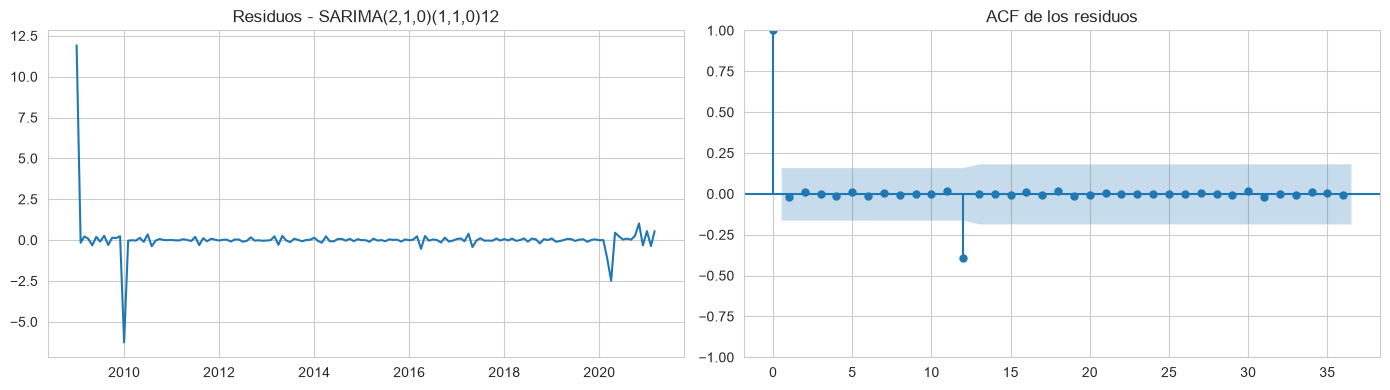

In [44]:
mejor_sarima_nombre = tabla_sarima[tabla_sarima['Modelo'].isin(resultados_sarima.keys())].iloc[0]['Modelo']
mejor_sarima = resultados_sarima[mejor_sarima_nombre]
print("Mejor modelo SARIMA por AIC:", mejor_sarima_nombre)

fig, axes = plt.subplots(1,2, figsize=(14,4))
axes[0].plot(mejor_sarima.resid)
axes[0].set_title(f'Residuos - {mejor_sarima_nombre}')
plot_acf(mejor_sarima.resid, lags=36, ax=axes[1])
axes[1].set_title('ACF de los residuos')
plt.tight_layout()
plt.show()

Los residuos del mejor modelo se ven sin patron claro alrededor de 0, aunque el ACF muestra un rezago puntual algo elevado cerca del 12 (consistente con el resultado marginal de Ljung-Box visto arriba). No es un ajuste perfecto, pero es razonable como modelo base de la familia ARIMA.

### 12.h Modelos alternativos: Prophet, Holt-Winters, suavizamiento exponencial simple y seasonal naive

In [45]:
# Holt-Winters (tendencia aditiva, estacionalidad multiplicativa)
modelo_hw = ExponentialSmoothing(serie_total_train, trend='add', seasonal='mul',
                                  seasonal_periods=12).fit()

# Suavizamiento exponencial simple (sin tendencia ni estacionalidad)
modelo_ses = ExponentialSmoothing(serie_total_train, trend=None, seasonal=None).fit()

# Seasonal naive: repite el mismo mes del ultimo ciclo anual observado
def seasonal_naive_forecast(train, h, m=12):
    ultimo_ciclo = train.iloc[-m:].values
    repeticiones = int(np.ceil(h/m))
    return np.tile(ultimo_ciclo, repeticiones)[:h]

# Prophet (estacionalidad multiplicativa, misma razon que en el punto d)
pdf = serie_total_train.reset_index()
pdf.columns = ['ds', 'y']
modelo_prophet = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True)
modelo_prophet.fit(pdf)

print("Holt-Winters      -> AIC:", round(modelo_hw.aic,1), "BIC:", round(modelo_hw.bic,1))
print("Suav. exp. simple -> AIC:", round(modelo_ses.aic,1), "BIC:", round(modelo_ses.bic,1))
print("Prophet y seasonal naive no tienen AIC/BIC clasico comparable.")

20:25:28 - cmdstanpy - INFO - Chain [1] start processing
20:25:29 - cmdstanpy - INFO - Chain [1] done processing


Holt-Winters      -> AIC: 3081.2 BIC: 3129.0
Suav. exp. simple -> AIC: 3177.2 BIC: 3183.2
Prophet y seasonal naive no tienen AIC/BIC clasico comparable.


**Holt-Winters:** modela nivel, tendencia y estacionalidad explicitamente con suavizamiento exponencial (aqui con estacionalidad multiplicativa, igual que decidimos para el log-ARIMA). **Suavizamiento exponencial simple:** solo nivel, sin tendencia ni estacionalidad — sirve de referencia base (*baseline*) para saber si vale la pena la complejidad de los demas modelos. **Seasonal naive:** predice repitiendo el valor del mismo mes del ultimo ciclo anual completo observado en entrenamiento — otro *baseline* simple pero fuerte cuando la estacionalidad es muy marcada, como en esta serie. **Prophet:** modelo con tendencia por tramos (*changepoints*) y estacionalidad anual via series de Fourier; se configuro con estacionalidad multiplicativa por la misma razon que el log-ARIMA.

Nota: como los AIC/BIC de Holt-Winters/SES estan calculados sobre la escala original (no log), tampoco son comparables numericamente contra los del SARIMA de la seccion anterior (escala log). Solo tienen sentido comparados entre si (HW vs SES) o dentro de cada familia.

### 12.i Prediccion del mejor modelo (ARIMA) sobre el conjunto de prueba

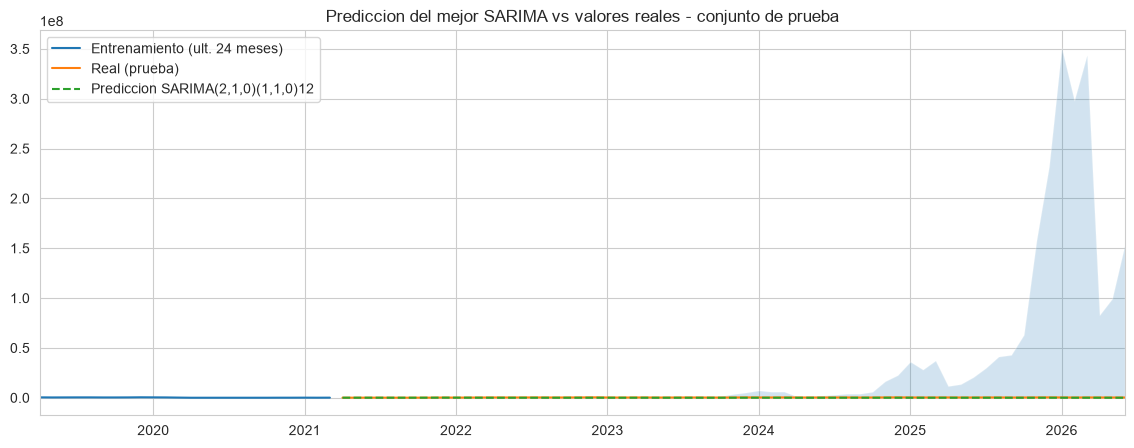

In [46]:
h = len(serie_total_test)

pred_log = mejor_sarima.get_forecast(steps=h)
pred_sarima = np.expm1(pred_log.predicted_mean)
ic_sarima = np.expm1(pred_log.conf_int(alpha=0.05))

fig, ax = plt.subplots(figsize=(14,5))
serie_total_train.iloc[-24:].plot(ax=ax, label='Entrenamiento (ult. 24 meses)')
serie_total_test.plot(ax=ax, label='Real (prueba)')
pred_sarima.plot(ax=ax, label=f'Prediccion {mejor_sarima_nombre}', style='--')
ax.fill_between(ic_sarima.index, ic_sarima.iloc[:,0], ic_sarima.iloc[:,1], alpha=0.2)
ax.set_title('Prediccion del mejor SARIMA vs valores reales - conjunto de prueba')
ax.legend()
plt.show()

El modelo SARIMA, entrenado solo con datos hasta marzo 2021 (antes de la recuperacion post-pandemia), subestima fuertemente el nivel de viajeros durante buena parte del periodo de prueba: extrapola la tendencia y estacionalidad aprendidas en un contexto todavia afectado por restricciones migratorias, y no anticipa la velocidad de la reapertura de fronteras en 2021-2022. Este es un limite esperable de un modelo ARIMA: proyecta patrones del pasado, no puede anticipar un cambio estructural que no estaba en los datos de entrenamiento.

### 12.j Comparacion de modelos: MAE, RMSE, AIC y BIC

In [47]:
def metricas(real, pred):
    real = np.asarray(real); pred = np.asarray(pred)
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred)**2))
    return mae, rmse

pred_hw = modelo_hw.forecast(h)
pred_ses = modelo_ses.forecast(h)
pred_sn = seasonal_naive_forecast(serie_total_train, h)

future_prophet = modelo_prophet.make_future_dataframe(periods=h, freq='MS')
fc_prophet = modelo_prophet.predict(future_prophet)
pred_prophet = fc_prophet.set_index('ds')['yhat'].iloc[-h:]

filas = []
for nombre, pred, aic, bic in [
    (mejor_sarima_nombre,          pred_sarima.values, mejor_sarima.aic, mejor_sarima.bic),
    ('Holt-Winters',               pred_hw.values,     modelo_hw.aic,    modelo_hw.bic),
    ('Suavizamiento exp. simple',  pred_ses.values,    modelo_ses.aic,   modelo_ses.bic),
    ('Seasonal naive',             pred_sn,            np.nan,           np.nan),
    ('Prophet',                    pred_prophet.values,np.nan,           np.nan),
]:
    mae, rmse = metricas(serie_total_test.values, pred)
    filas.append({'Modelo': nombre, 'MAE': round(mae,1), 'RMSE': round(rmse,1),
                  'AIC': round(aic,1) if pd.notna(aic) else np.nan,
                  'BIC': round(bic,1) if pd.notna(bic) else np.nan})

tabla_comparacion = pd.DataFrame(filas).sort_values('RMSE').reset_index(drop=True)
tabla_comparacion

,Modelo,MAE,RMSE,AIC,BIC
0,Prophet,113358.9,119739.5,NaN,NaN
1,Holt-Winters,134374.8,146605.6,3081.2,3129.0
2,Suavizamiento exp. simple,165372.5,180598.2,3177.2,3183.2
3,Seasonal naive,207321.6,219663.9,NaN,NaN
4,"SARIMA(2,1,0)(1,1,0)12",226436.9,242858.0,65.4,77.0


### 12.k Seleccion del mejor modelo

Sobre el conjunto de prueba (63 meses, abril 2021 a junio 2026), **Prophet** obtiene el menor MAE y RMSE (aprox. 113,359 y 119,739), seguido de **Holt-Winters** (aprox. 134,375 y 146,606). El SARIMA y el seasonal naive quedan mas atras, y el suavizamiento exponencial simple queda en un punto intermedio. Esto es consistente con lo discutido en el punto anterior: Prophet maneja explicitamente cambios de tendencia (*changepoints*), lo que le permite adaptarse mejor a un quiebre estructural como la reapertura pos-pandemia, mientras que el SARIMA extrapola linealmente el comportamiento aprendido antes del quiebre.

Para esta serie (total mensual), el **mejor modelo es Prophet**. Aun asi, el mejor SARIMA sigue siendo util como modelo de referencia interpretable, construido con la metodologia clasica de Box-Jenkins (ACF/PACF, diferenciacion, AIC/BIC).

## 13. Funcion generalizada del pipeline (para replicar en las demas series)

Empaquetamos los pasos de las secciones 12.a-12.k en una funcion `analizar_serie` para aplicarla de forma sistematica a las otras 7 series (vias de ingreso y tipos de viajero). La funcion usa `log1p` (soporta ceros, util para Marítima y Cruceristas), evalua 2 candidatos SARIMA manuales mas el de `auto_arima`, ajusta Holt-Winters/SES/seasonal naive/Prophet, y devuelve la tabla comparativa de MAE/RMSE/AIC/BIC junto con el mejor modelo de cada familia.

In [48]:
def analizar_serie(serie_train, serie_test, nombre, seasonal_periods=12, verbose=True):
    '''Aplica el pipeline de las secciones 12.a-12.k a una serie mensual cualquiera.
    Devuelve un diccionario con la tabla comparativa de modelos y el mejor modelo.'''
    h = len(serie_test)

    if verbose:
        print(f"\n{'='*70}\n{nombre}\n{'='*70}")
        print(f"Train: {serie_train.index.min().date()} a {serie_train.index.max().date()} "
              f"({len(serie_train)} meses) | Test: {serie_test.index.min().date()} a "
              f"{serie_test.index.max().date()} ({len(serie_test)} meses)")
        fig, ax = plt.subplots(figsize=(12,4))
        serie_train.plot(ax=ax, label='Entrenamiento')
        serie_test.plot(ax=ax, label='Prueba')
        ax.axvline(serie_test.index.min(), color='gray', linestyle='--')
        ax.set_title(f'{nombre} - serie mensual')
        ax.legend()
        plt.show()

    serie_log = np.log1p(serie_train)

    try:
        decomp = seasonal_decompose(serie_train, model='multiplicative', period=seasonal_periods)
    except ValueError:
        decomp = seasonal_decompose(serie_train, model='additive', period=seasonal_periods)
    if verbose:
        fig = decomp.plot(); fig.set_size_inches(10,6); plt.show()

    adf_nivel = adfuller(serie_log, autolag='AIC')
    serie_log_diff = serie_log.diff().diff(seasonal_periods).dropna()
    adf_diff = adfuller(serie_log_diff, autolag='AIC')
    if verbose:
        print(f"ADF nivel (log): p={adf_nivel[1]:.4f} | ADF diferenciada (d=1,D=1): p={adf_diff[1]:.4f}")
        fig, axes = plt.subplots(1,2, figsize=(12,4))
        plot_acf(serie_log, lags=min(36, len(serie_log)//2 - 1), ax=axes[0])
        axes[0].set_title('ACF - nivel (log)')
        plot_pacf(serie_log_diff, lags=min(36, len(serie_log_diff)//2 - 1), ax=axes[1], method='ywm')
        axes[1].set_title('PACF - diferenciada (d=1,D=1)')
        plt.tight_layout(); plt.show()

    auto_model = pm.auto_arima(serie_log, seasonal=True, m=seasonal_periods, stepwise=True,
                                suppress_warnings=True, error_action='ignore',
                                max_p=3, max_q=3, max_P=2, max_Q=2)

    candidatos = {
        f'Manual (1,1,1)(1,1,1){seasonal_periods}': ((1,1,1), (1,1,1,seasonal_periods)),
        f'(0,1,1)(0,1,1){seasonal_periods}':        ((0,1,1), (0,1,1,seasonal_periods)),
    }
    ajustes = {}
    for cn, (order, sorder) in candidatos.items():
        try:
            ajustes[cn] = SARIMAX(serie_log, order=order, seasonal_order=sorder,
                                   enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)
        except Exception:
            continue

    nombre_auto = f'auto_arima {auto_model.order}x{auto_model.seasonal_order}'
    filas_sarima = [(cn, a.aic, a.bic,
                      acorr_ljungbox(a.resid, lags=[seasonal_periods], return_df=True)['lb_pvalue'].iloc[0])
                     for cn, a in ajustes.items()]
    filas_sarima.append((nombre_auto, auto_model.aic(), auto_model.bic(),
                          acorr_ljungbox(auto_model.resid(), lags=[seasonal_periods], return_df=True)['lb_pvalue'].iloc[0]))

    tabla_sarima = pd.DataFrame(filas_sarima, columns=['Modelo','AIC','BIC','Ljung-Box p']).sort_values('AIC').reset_index(drop=True)
    if verbose:
        print(tabla_sarima)

    mejor_nombre = tabla_sarima.iloc[0]['Modelo']
    if mejor_nombre == nombre_auto:
        pred_sarima = pd.Series(np.expm1(auto_model.predict(n_periods=h)), index=serie_test.index)
    else:
        pred_sarima = np.expm1(ajustes[mejor_nombre].get_forecast(steps=h).predicted_mean)

    try:
        modelo_hw = ExponentialSmoothing(serie_train, trend='add', seasonal='mul',
                                          seasonal_periods=seasonal_periods).fit()
    except ValueError:
        modelo_hw = ExponentialSmoothing(serie_train, trend='add', seasonal='add',
                                          seasonal_periods=seasonal_periods).fit()
    modelo_ses = ExponentialSmoothing(serie_train, trend=None, seasonal=None).fit()
    pred_sn = seasonal_naive_forecast(serie_train, h, seasonal_periods)

    pdf = serie_train.reset_index(); pdf.columns = ['ds', 'y']
    modelo_prophet = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True)
    modelo_prophet.fit(pdf)
    future = modelo_prophet.make_future_dataframe(periods=h, freq='MS')
    pred_prophet = modelo_prophet.predict(future).set_index('ds')['yhat'].iloc[-h:]

    pred_hw = modelo_hw.forecast(h)
    pred_ses = modelo_ses.forecast(h)

    fila_sarima_tabla = tabla_sarima.iloc[0]
    filas = []
    for mn, pred, aic, bic in [
        (mejor_nombre,              np.asarray(pred_sarima), fila_sarima_tabla['AIC'], fila_sarima_tabla['BIC']),
        ('Holt-Winters',            pred_hw.values,          modelo_hw.aic,  modelo_hw.bic),
        ('Suav. exp. simple',       pred_ses.values,         modelo_ses.aic, modelo_ses.bic),
        ('Seasonal naive',          pred_sn,                 np.nan,         np.nan),
        ('Prophet',                 pred_prophet.values,     np.nan,         np.nan),
    ]:
        mae, rmse = metricas(serie_test.values, pred)
        filas.append({'Modelo': mn, 'MAE': round(mae,1), 'RMSE': round(rmse,1),
                      'AIC': round(aic,1) if pd.notna(aic) else np.nan,
                      'BIC': round(bic,1) if pd.notna(bic) else np.nan})
    tabla_comparacion = pd.DataFrame(filas).sort_values('RMSE').reset_index(drop=True)

    if verbose:
        print(tabla_comparacion)
        fig, ax = plt.subplots(figsize=(12,4))
        serie_test.plot(ax=ax, label='Real')
        pd.Series(np.asarray(pred_sarima), index=serie_test.index).plot(ax=ax, label=f'SARIMA ({mejor_nombre})', style='--')
        pd.Series(pred_prophet.values, index=serie_test.index).plot(ax=ax, label='Prophet', style='--')
        ax.set_title(f'{nombre} - prediccion vs real (prueba)')
        ax.legend(); plt.show()

    return {
        'nombre': nombre,
        'tabla_sarima': tabla_sarima,
        'tabla_comparacion': tabla_comparacion,
        'mejor_sarima_nombre': mejor_nombre,
        'mejor_modelo_global': tabla_comparacion.iloc[0]['Modelo'],
        'adf_p_nivel': adf_nivel[1],
        'adf_p_diferenciada': adf_diff[1],
    }

print("Funcion analizar_serie definida.")

Funcion analizar_serie definida.


## 14. Aplicacion del pipeline a las demas series (vias de ingreso y tipo de viajero)

Aplicamos la funcion `analizar_serie` definida en la seccion 13 a las 7 series restantes: las 3 series de **via de ingreso** (Aerea, Terrestre, Maritima) y las 4 de **tipo de viajero** (Turista, Excursionista, Cruceristas, Viajero). Para cada una se construye primero la serie de prueba correspondiente (analoga a `serie_total_test`) y luego se corre el pipeline completo (grafico, descomposicion, ADF, ACF/PACF, SARIMA vs auto_arima, Prophet/Holt-Winters/SES/seasonal naive, prediccion y tabla de metricas).

In [49]:
series_via_test = {}
for via in vias:
    filtro = df_test['Vía'] == via
    series_via_test[via] = construir_serie(df_test, filtro, rango_test)

series_tipo_test = {}
for tipo in tipos:
    filtro = df_test['Tipo de Viajero'] == tipo
    series_tipo_test[tipo] = construir_serie(df_test, filtro, rango_test)

print("Series de prueba construidas para vias:", list(series_via_test.keys()))
print("Series de prueba construidas para tipos:", list(series_tipo_test.keys()))

Series de prueba construidas para vias: ['Aérea', 'Terrestre', 'Marítima']
Series de prueba construidas para tipos: ['Turista', 'Excursionista', 'Cruceristas', 'Viajero']


### 14.1 Vias de ingreso


Via Aérea
Train: 2009-01-01 a 2021-03-01 (147 meses) | Test: 2021-04-01 a 2026-06-01 (63 meses)


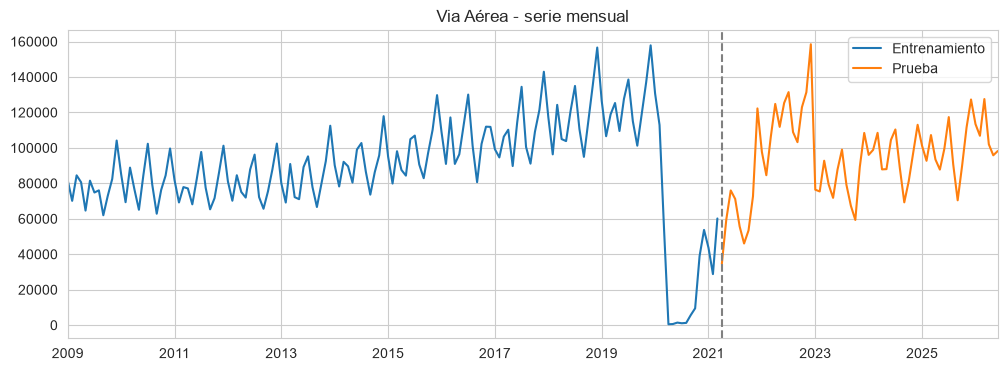

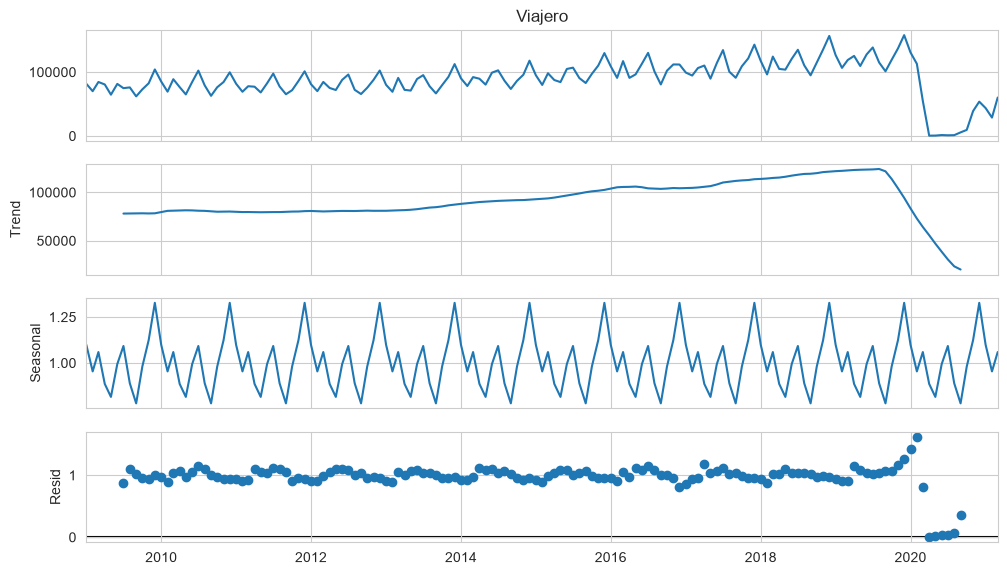

ADF nivel (log): p=0.0013 | ADF diferenciada (d=1,D=1): p=0.0000


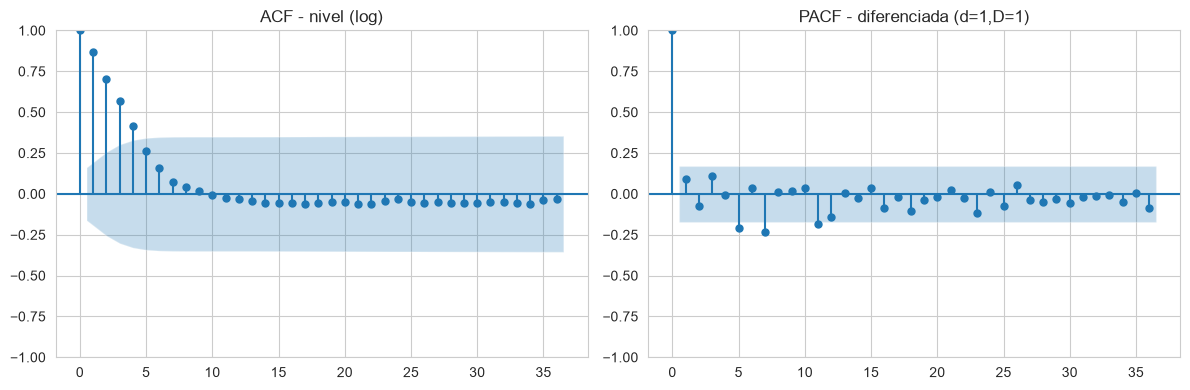

                               Modelo         AIC         BIC  Ljung-Box p
0  auto_arima (1, 0, 1)x(1, 0, 1, 12)  185.471116  203.413712     0.260284
1                    (0,1,1)(0,1,1)12  185.721005  194.414525     0.053533
2             Manual (1,1,1)(1,1,1)12  191.284804  205.774003     0.058637


20:25:54 - cmdstanpy - INFO - Chain [1] start processing
20:25:54 - cmdstanpy - INFO - Chain [1] done processing


                               Modelo      MAE     RMSE     AIC     BIC
0                        Holt-Winters  24619.3  29846.3  2733.4  2781.3
1  auto_arima (1, 0, 1)x(1, 0, 1, 12)  29700.1  34728.7   185.5   203.4
2                   Suav. exp. simple  36108.5  41367.8  2875.3  2881.3
3                             Prophet  42316.5  47086.0     NaN     NaN
4                      Seasonal naive  75103.7  79077.3     NaN     NaN


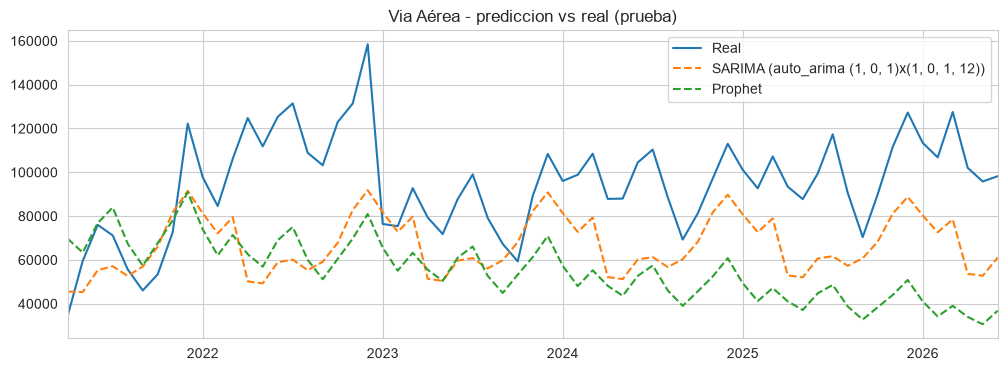


Via Terrestre
Train: 2009-01-01 a 2021-03-01 (147 meses) | Test: 2021-04-01 a 2026-06-01 (63 meses)


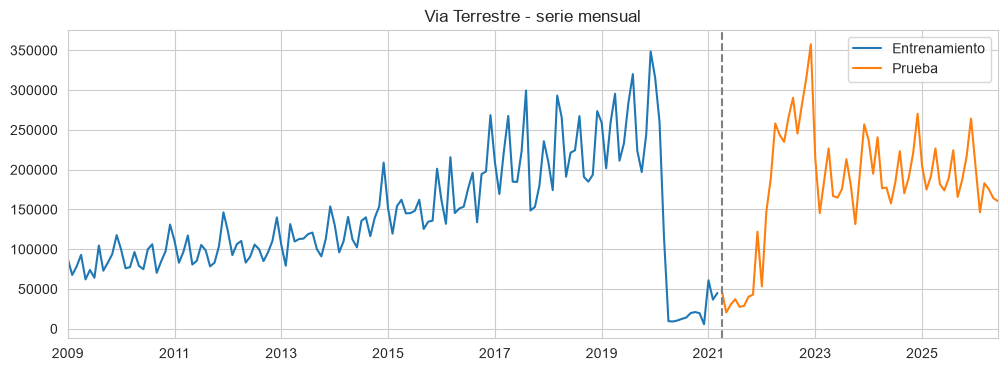

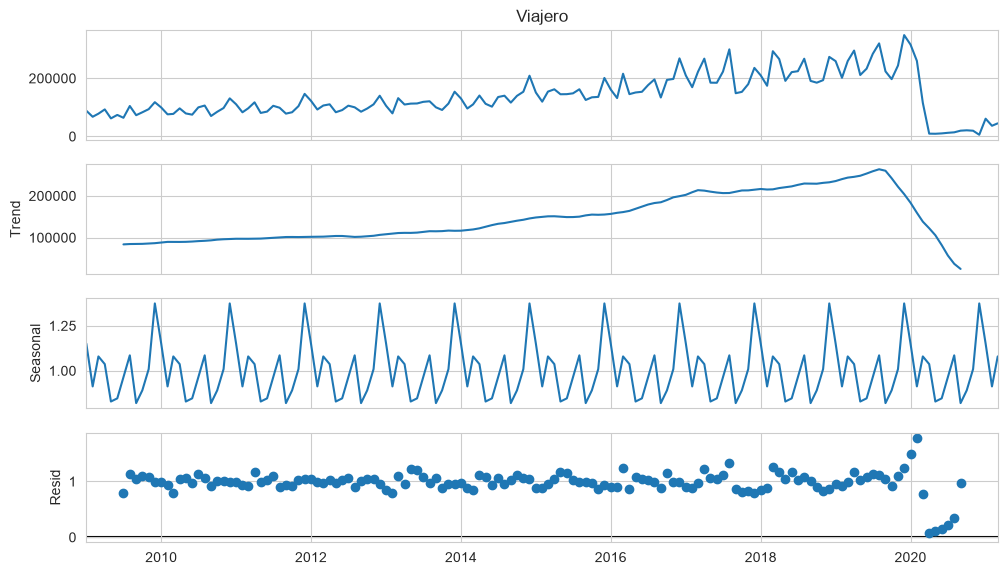

ADF nivel (log): p=0.5619 | ADF diferenciada (d=1,D=1): p=0.0000


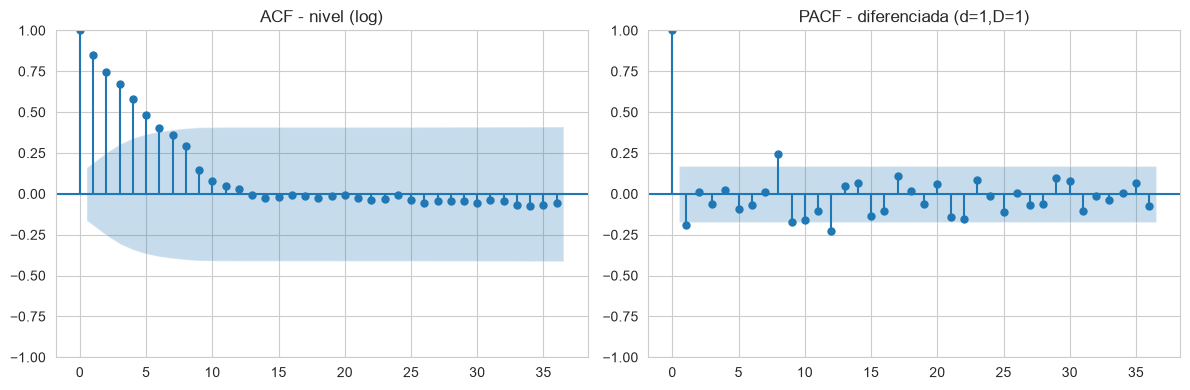

20:26:07 - cmdstanpy - INFO - Chain [1] start processing


                               Modelo         AIC         BIC  Ljung-Box p
0  auto_arima (1, 0, 0)x(0, 0, 2, 12)  128.316408  143.268571     0.027569
1                    (0,1,1)(0,1,1)12  130.067700  138.761220     0.029579
2             Manual (1,1,1)(1,1,1)12  133.358825  147.848024     0.031002


20:26:07 - cmdstanpy - INFO - Chain [1] done processing


                               Modelo       MAE      RMSE     AIC     BIC
0                             Prophet   56785.5   72569.6     NaN     NaN
1  auto_arima (1, 0, 0)x(0, 0, 2, 12)  106442.6  125767.5   128.3   143.3
2                        Holt-Winters  119819.9  135351.2  3027.9  3075.8
3                   Suav. exp. simple  140736.1  156653.4  3121.0  3127.0
4                      Seasonal naive  160013.0  176653.0     NaN     NaN


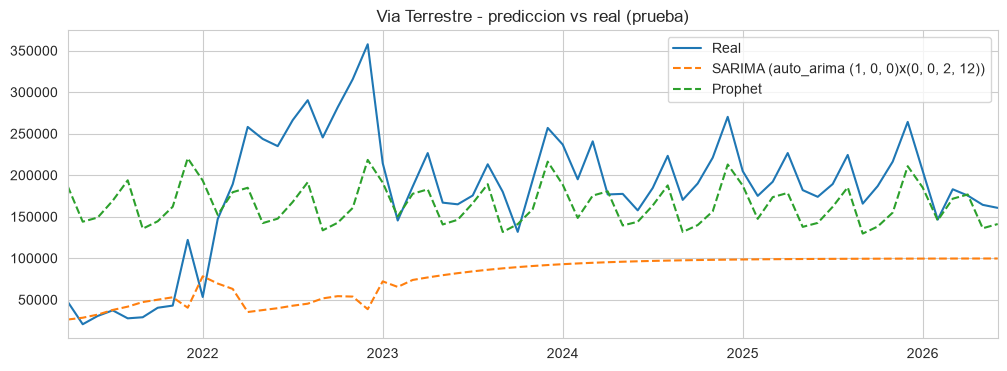


Via Marítima
Train: 2009-01-01 a 2021-03-01 (147 meses) | Test: 2021-04-01 a 2026-06-01 (63 meses)


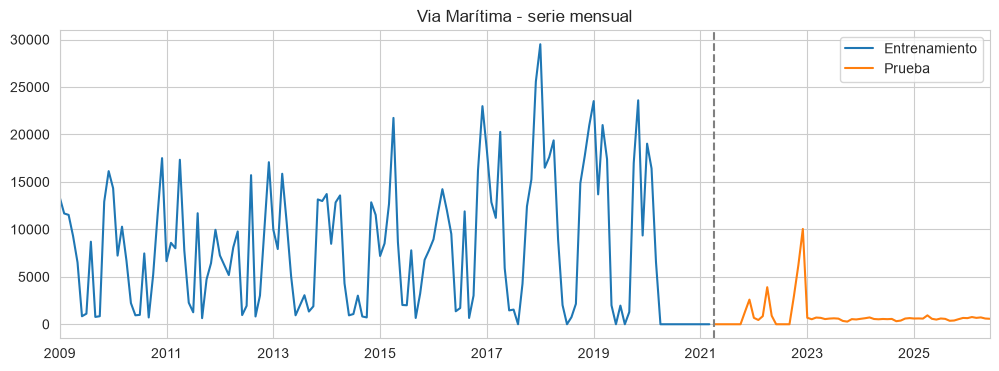

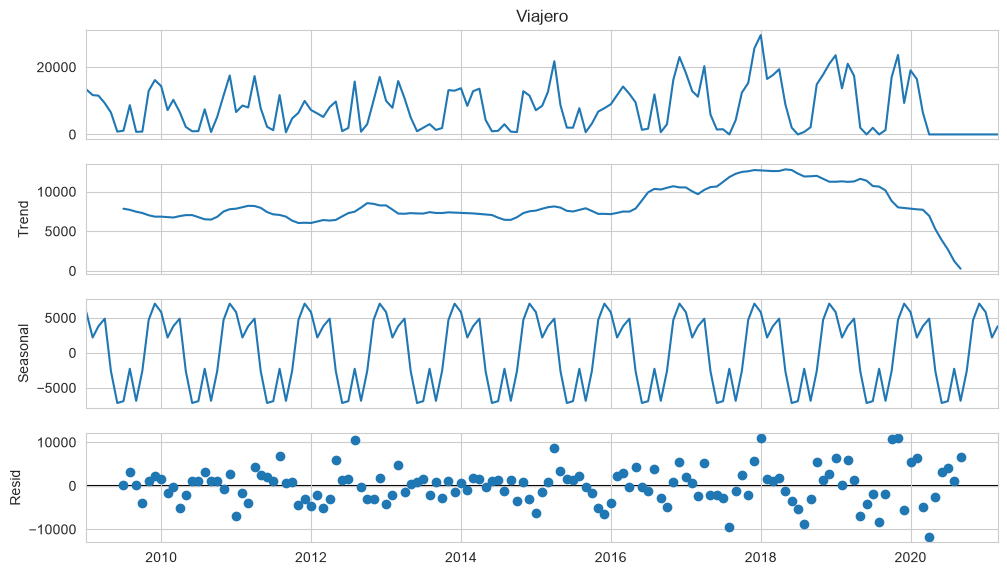

ADF nivel (log): p=1.0000 | ADF diferenciada (d=1,D=1): p=0.1327


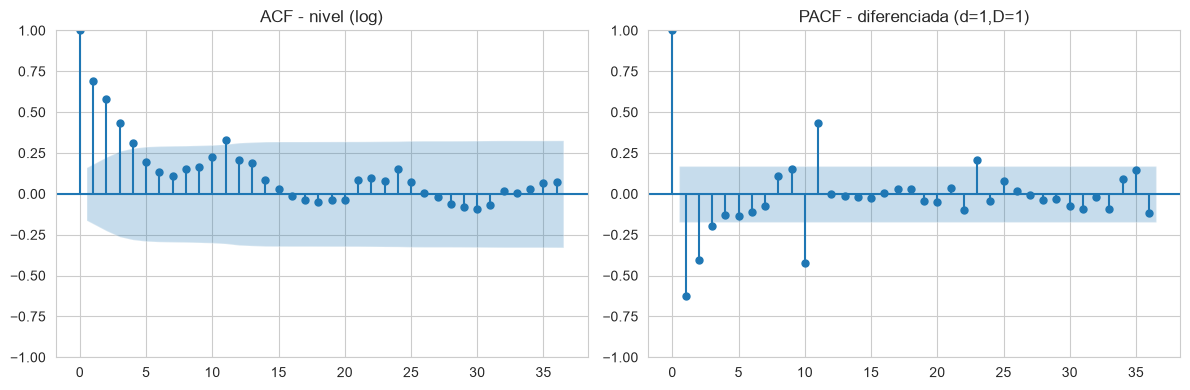

20:26:15 - cmdstanpy - INFO - Chain [1] start processing


                               Modelo         AIC         BIC  Ljung-Box p
0             Manual (1,1,1)(1,1,1)12  562.222371  576.711570     0.027951
1                    (0,1,1)(0,1,1)12  565.349536  574.043055     0.003534
2  auto_arima (0, 1, 1)x(2, 0, 0, 12)  601.577202  613.511628     0.000673


20:26:15 - cmdstanpy - INFO - Chain [1] done processing


                    Modelo     MAE    RMSE     AIC     BIC
0           Seasonal naive   858.4  1731.9     NaN     NaN
1        Suav. exp. simple   858.4  1731.9  2569.3  2575.2
2  Manual (1,1,1)(1,1,1)12   859.3  1732.4   562.2   576.7
3                  Prophet  3840.8  4838.5     NaN     NaN
4             Holt-Winters  7541.4  8849.5  2503.9  2551.7


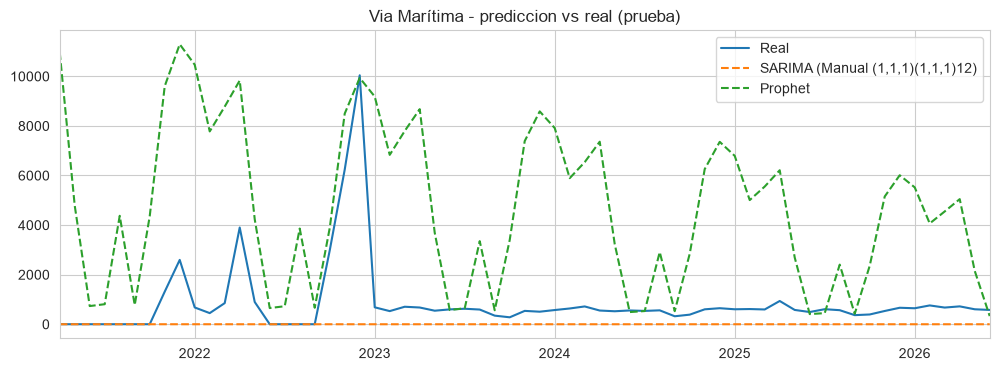

In [50]:
resultados_via = {}
for via in vias:
    resultados_via[via] = analizar_serie(series_via[via], series_via_test[via], f"Via {via}")

### 14.2 Tipo de viajero


Tipo Turista
Train: 2009-01-01 a 2021-03-01 (147 meses) | Test: 2021-04-01 a 2026-06-01 (63 meses)


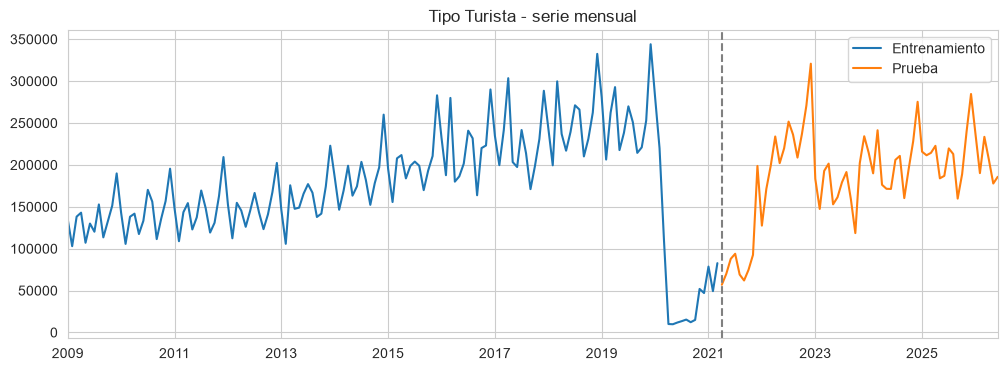

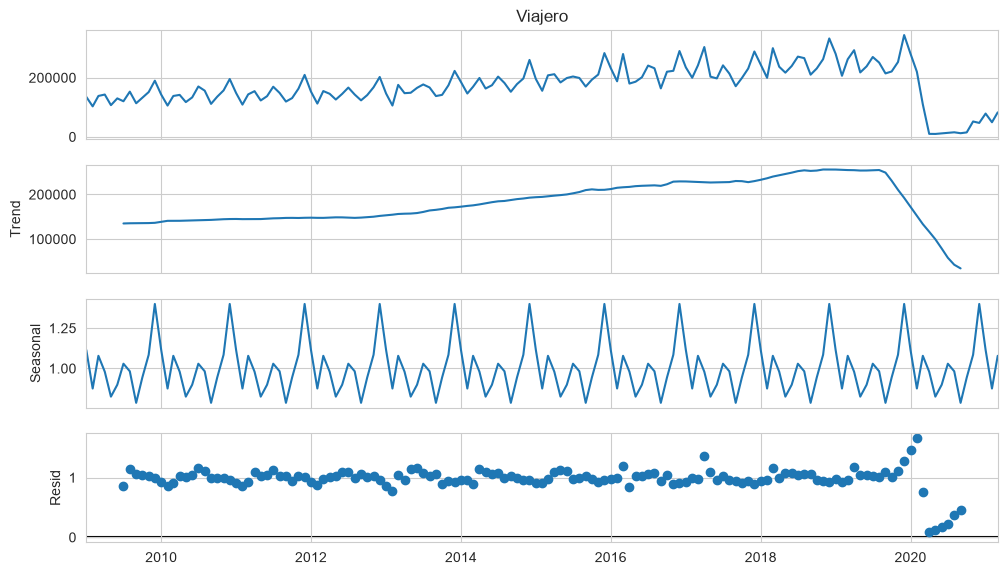

ADF nivel (log): p=0.1973 | ADF diferenciada (d=1,D=1): p=0.0000


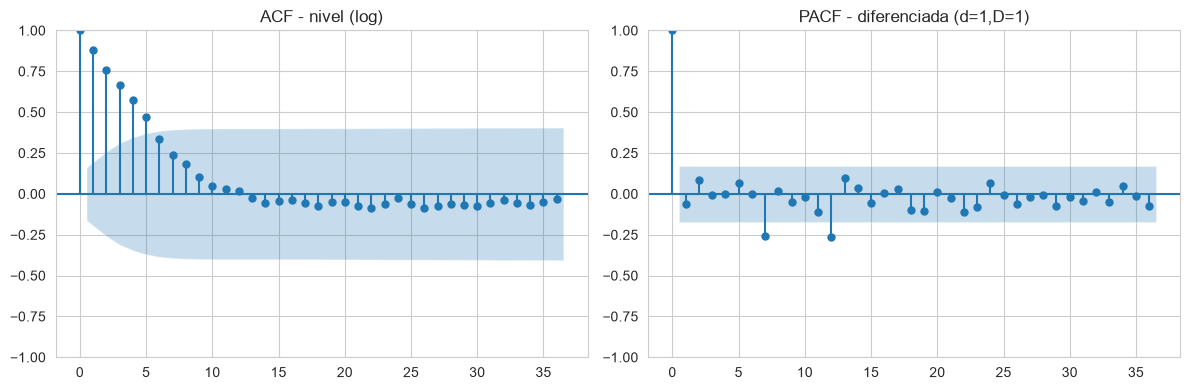

20:26:30 - cmdstanpy - INFO - Chain [1] start processing


                               Modelo        AIC        BIC  Ljung-Box p
0             Manual (1,1,1)(1,1,1)12  46.494595  60.983794     0.014154
1  auto_arima (2, 0, 2)x(2, 0, 0, 12)  48.142427  72.065887     0.755768
2                    (0,1,1)(0,1,1)12  50.152687  58.846206     0.012448


20:26:30 - cmdstanpy - INFO - Chain [1] done processing


                    Modelo       MAE      RMSE     AIC     BIC
0             Holt-Winters   89353.6   98749.8  2999.3  3047.2
1        Suav. exp. simple  116883.4  128488.1  3118.9  3124.9
2                  Prophet  129869.2  141740.3     NaN     NaN
3           Seasonal naive  155607.8  164460.4     NaN     NaN
4  Manual (1,1,1)(1,1,1)12  165131.2  178725.0    46.5    61.0


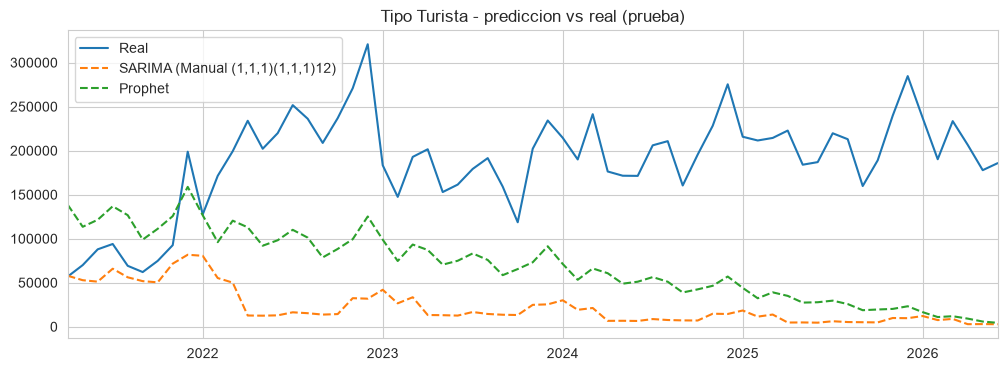


Tipo Excursionista
Train: 2009-01-01 a 2021-03-01 (147 meses) | Test: 2021-04-01 a 2026-06-01 (63 meses)


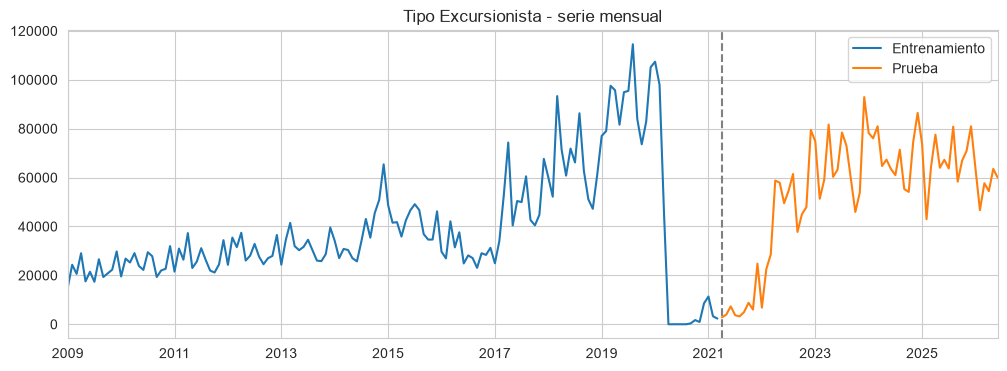

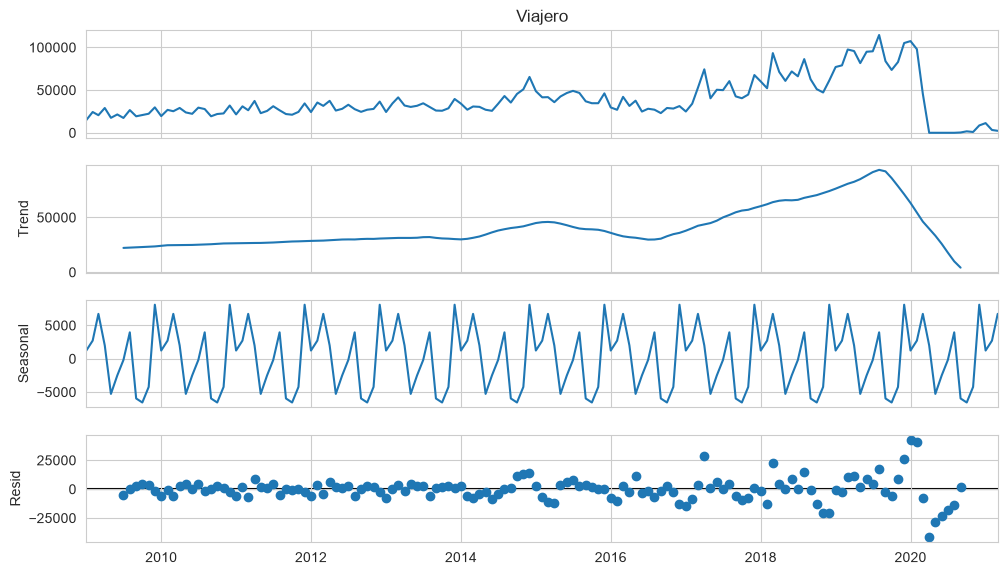

ADF nivel (log): p=0.0257 | ADF diferenciada (d=1,D=1): p=0.0000


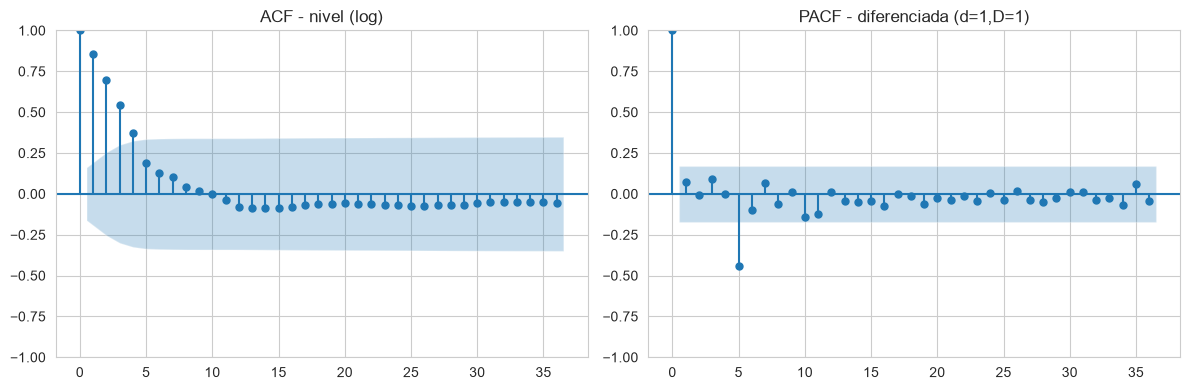

                               Modelo         AIC         BIC  Ljung-Box p
0  auto_arima (0, 1, 0)x(0, 1, 0, 12)  413.661721  416.559560     0.071253
1                    (0,1,1)(0,1,1)12  415.965458  424.658977     0.100261
2             Manual (1,1,1)(1,1,1)12  418.649930  433.139129     0.112869


20:26:33 - cmdstanpy - INFO - Chain [1] start processing
20:26:33 - cmdstanpy - INFO - Chain [1] done processing


                               Modelo      MAE     RMSE     AIC     BIC
0                             Prophet  15517.9  22427.4     NaN     NaN
1                   Suav. exp. simple  51498.5  56874.7  2756.6  2762.6
2                      Seasonal naive  51858.4  56914.1     NaN     NaN
3  auto_arima (0, 1, 0)x(0, 1, 0, 12)  53954.7  59122.5   413.7   416.6
4                        Holt-Winters  65536.3  71203.1  2757.2  2805.1


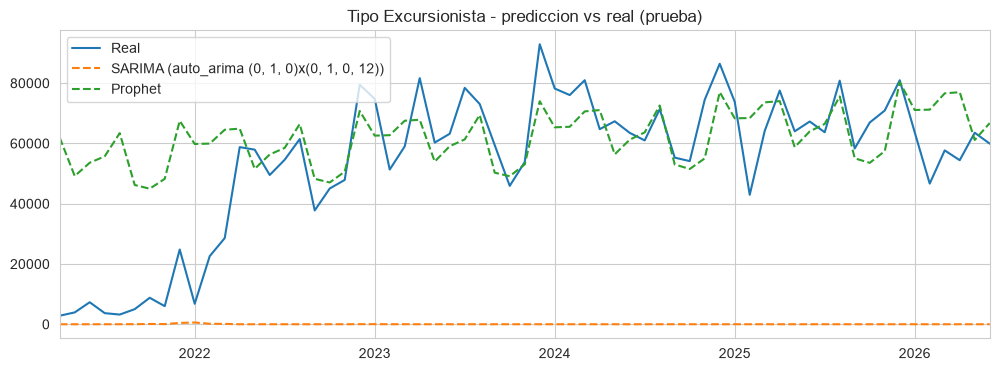


Tipo Cruceristas
Train: 2009-01-01 a 2021-03-01 (147 meses) | Test: 2021-04-01 a 2026-06-01 (63 meses)


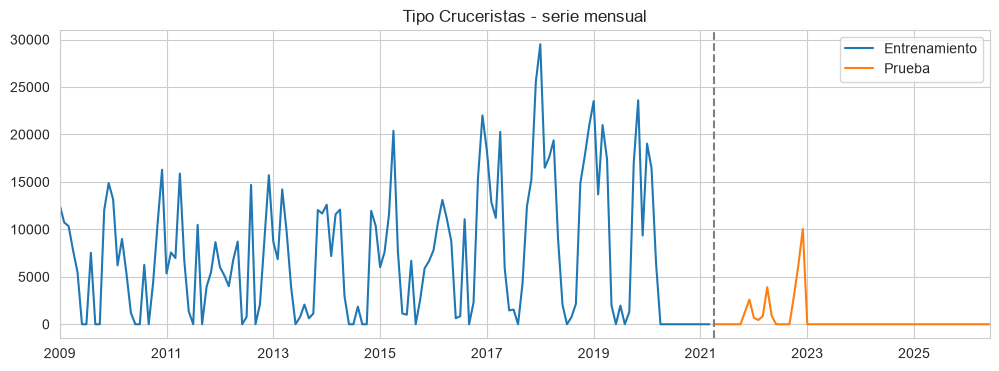

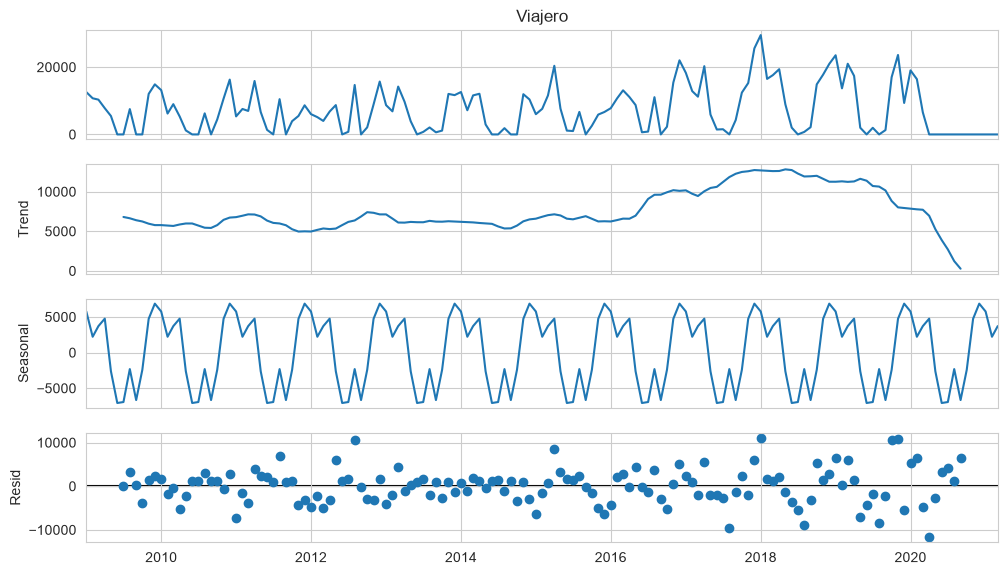

ADF nivel (log): p=0.9691 | ADF diferenciada (d=1,D=1): p=0.0006


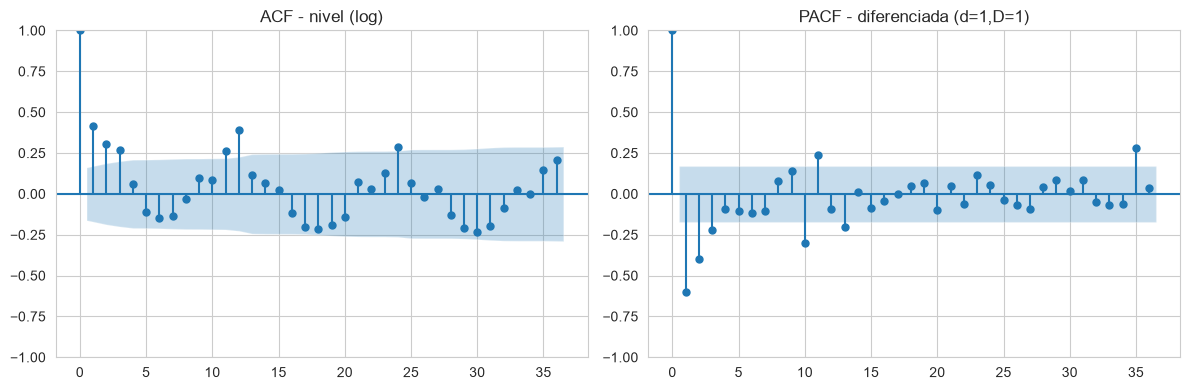

20:26:54 - cmdstanpy - INFO - Chain [1] start processing


                               Modelo         AIC         BIC  Ljung-Box p
0                    (0,1,1)(0,1,1)12  664.135767  672.829287     0.040837
1             Manual (1,1,1)(1,1,1)12  666.345632  680.834831     0.036618
2  auto_arima (1, 0, 1)x(1, 0, 1, 12)  731.667853  746.620016     0.232752


20:26:54 - cmdstanpy - INFO - Chain [1] done processing


              Modelo     MAE    RMSE     AIC     BIC
0     Seasonal naive   475.2  1664.2     NaN     NaN
1  Suav. exp. simple   475.2  1664.2  2565.3  2571.3
2   (0,1,1)(0,1,1)12   476.2  1664.5   664.1   672.8
3            Prophet  5063.4  6309.5     NaN     NaN
4       Holt-Winters  7022.2  8361.2  2503.0  2550.8


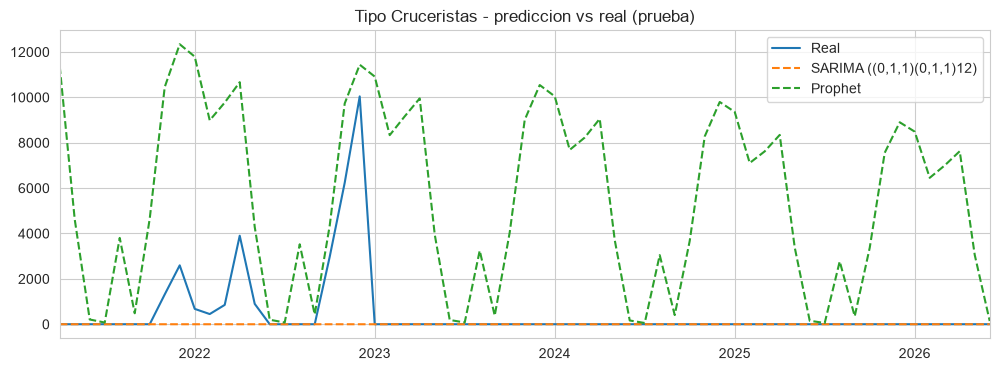


Tipo Viajero
Train: 2009-01-01 a 2021-03-01 (147 meses) | Test: 2021-04-01 a 2026-06-01 (63 meses)


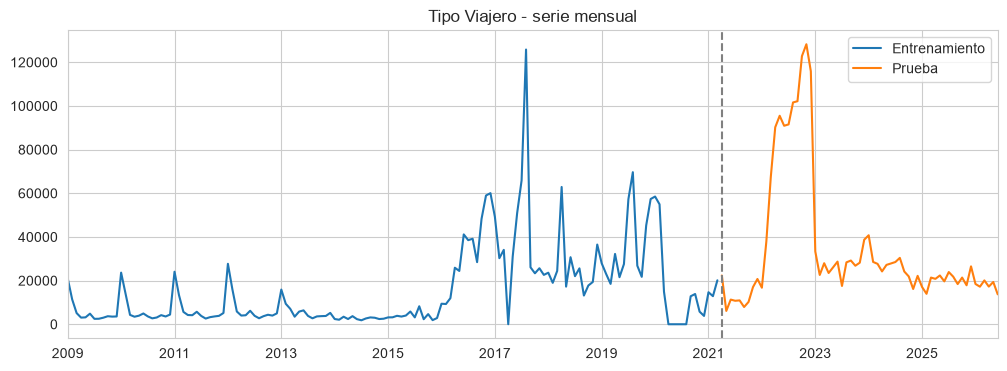

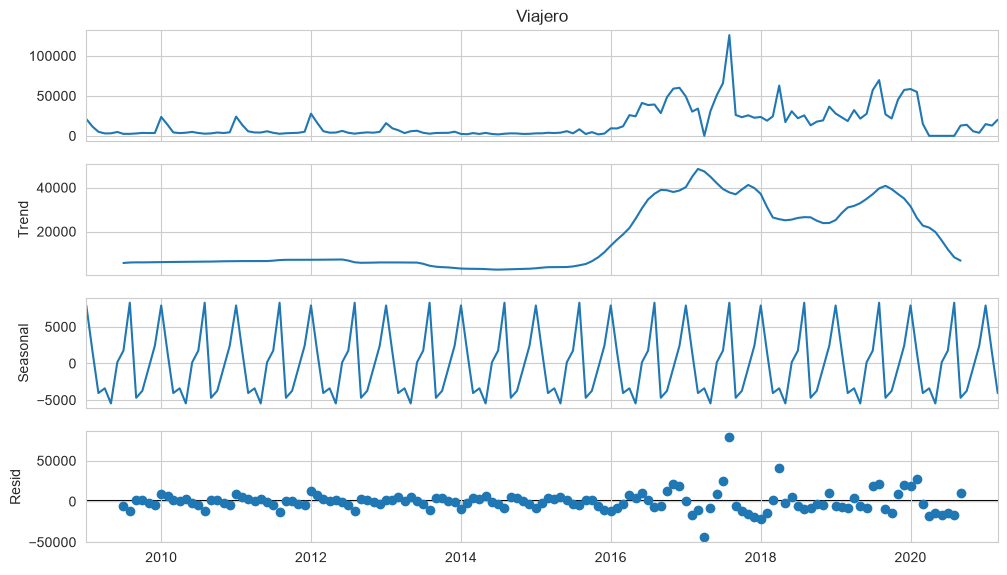

ADF nivel (log): p=0.0000 | ADF diferenciada (d=1,D=1): p=0.0000


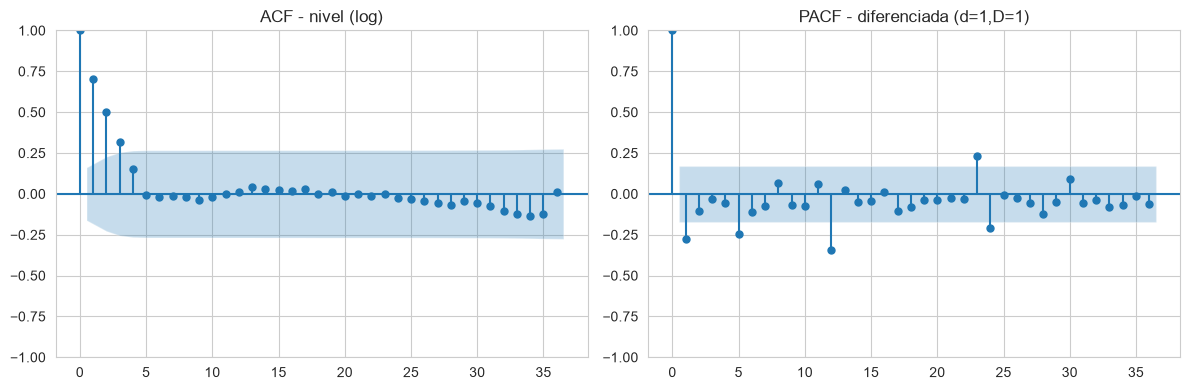

20:26:57 - cmdstanpy - INFO - Chain [1] start processing


                               Modelo         AIC         BIC  Ljung-Box p
0             Manual (1,1,1)(1,1,1)12  518.112663  532.601862     0.852013
1                    (0,1,1)(0,1,1)12  525.815041  534.508560     0.396224
2  auto_arima (1, 0, 0)x(0, 0, 0, 12)  532.135445  541.106743     0.776677


20:26:57 - cmdstanpy - INFO - Chain [1] done processing


                    Modelo      MAE     RMSE     AIC     BIC
0                  Prophet  23659.5  33295.9     NaN     NaN
1             Holt-Winters  23092.5  34598.1  2820.1  2868.0
2        Suav. exp. simple  19469.4  35143.4  2808.9  2814.9
3  Manual (1,1,1)(1,1,1)12  24687.3  39511.5   518.1   532.6
4           Seasonal naive  28208.0  42001.8     NaN     NaN


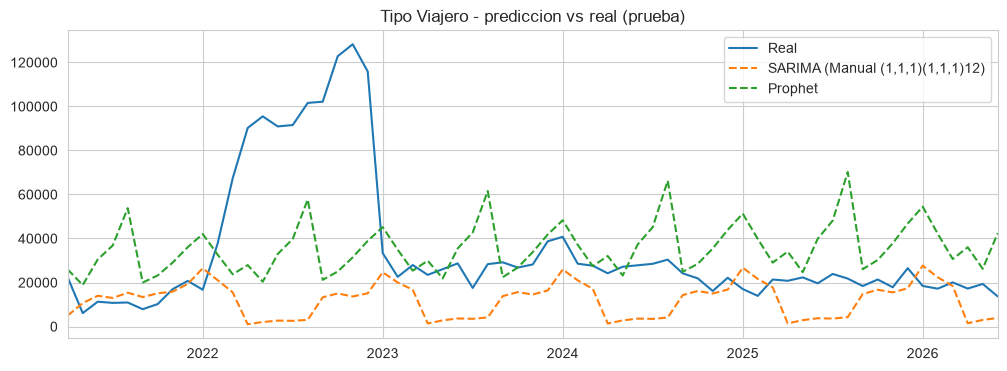

In [51]:
resultados_tipo = {}
for tipo in tipos:
    resultados_tipo[tipo] = analizar_serie(series_tipo[tipo], series_tipo_test[tipo], f"Tipo {tipo}")

### 14.3 Resumen: mejor modelo por serie

Tabla con el modelo que gano (menor RMSE en el conjunto de prueba) para cada una de las 8 series, que usaremos como base cuantitativa para el analisis comparativo del punto 5.

In [52]:
resumen_modelos = []
fila_total = tabla_comparacion.iloc[0]
resumen_modelos.append({'Serie': 'Total (obligatoria)', 'Mejor modelo': fila_total['Modelo'],
                         'MAE': fila_total['MAE'], 'RMSE': fila_total['RMSE']})
for via, res in resultados_via.items():
    fila = res['tabla_comparacion'].iloc[0]
    resumen_modelos.append({'Serie': f'Via {via}', 'Mejor modelo': fila['Modelo'],
                             'MAE': fila['MAE'], 'RMSE': fila['RMSE']})
for tipo, res in resultados_tipo.items():
    fila = res['tabla_comparacion'].iloc[0]
    resumen_modelos.append({'Serie': f'Tipo {tipo}', 'Mejor modelo': fila['Modelo'],
                             'MAE': fila['MAE'], 'RMSE': fila['RMSE']})

pd.DataFrame(resumen_modelos)

,Serie,Mejor modelo,MAE,RMSE
0,Total (obligatoria),Prophet,113358.9,119739.5
1,Via Aérea,Holt-Winters,24619.3,29846.3
2,Via Terrestre,Prophet,56785.5,72569.6
3,Via Marítima,Seasonal naive,858.4,1731.9
4,Tipo Turista,Holt-Winters,89353.6,98749.8
5,Tipo Excursionista,Prophet,15517.9,22427.4
6,Tipo Cruceristas,Seasonal naive,475.2,1664.2
7,Tipo Viajero,Prophet,23659.5,33295.9
